
# FSC ↔ tinyRNN pipeline

Two independent ways of extracting a **minimal, interpretable model of decision-making**
from the same behavioral data:

1. **Finite State Controller (FSC)** — Nicoletti & Celani, *"Decoding behavior with
   minimal and interpretable agent models"* (2026). A discrete-state controller fit by
   MAPSO (particle-swarm) + gradient descent.
   Code: [`FSC-inference-MAPSO`](https://github.com/giorgionicoletti/FSC-inference-MAPSO)
2. **tinyRNN** — Ji-An, Benna & Mattar, *"Discovering cognitive strategies with tiny
   recurrent neural networks"* (Nature, 2025). A small GRU trained with the paper's
   official nested cross-validation procedure to find the smallest RNN that explains
   the behavior.
   Code: [`tinyRNN`](https://github.com/cgc/tinyRNN)

## A note on fidelity
Both repos are vendored (git-cloned) rather than reimplemented, and the training /
inference calls below follow the authors' own example notebooks / experiment scripts
as closely as possible, so that nothing about *how* the models are fit is invented here.


- **Everything from Section 4 on** is analysis code we write ourselves, organised by
  question rather than by model: each section asks one thing and answers it for the FSC and
  the RNN side by side.
  Where it touches the FSC's internal dynamics (the belief-state decoder), it is a
  direct implementation of the same forward-filtering recursion the library itself
  computes inside `inference.loss` (see Section 4.1), not a new model.

## Reproducibility — how someone else runs this
The two upstream repos are **not** committed to this project's repo; Section 0 `git clone`s
them fresh (`--depth 1`) into `FSC-inference-MAPSO/` and `tinyRNN/`. So a fresh checkout of
this project is just the notebook, the `wsls_actions_observations.npz` data, and the
`fitted_models/` artifacts — you run Section 0 once and the libraries appear locally.

The **only** modifications made to those cloned libraries are two automated patches that
Section 0 applies itself (idempotently) each run:
1. `path_settings.py` — replace the upstream hardcoded Windows `MODEL_SAVE_PATH` with a
   local relative path, so the notebook is portable.
2. `datasets/SimpleDataset.py` — a one-line upstream bug fix for variable-length sessions.

Because both patches live in the notebook (not hand-edits made outside it), a fresh clone +
run reproduces them exactly — nothing about the fitted models depends on manual edits.
The `fitted_models/` directory ships the already-fit results (FSC sweep + the full RNN
nested-CV) so you can explore Sections 2.3/3.3 onward without re-running the (slow) fits;
delete it (or flip the `FORCE_*` toggles) to regenerate from scratch.

## Requirements
Python ≥3.10, and (installed in Section 0): `torch`, `numpy`, `scipy`, `pandas`,
`scikit-learn`, `statsmodels`, `numba`, `networkx`, `joblib`, `matplotlib`, `tqdm`.
tinyRNN training is CPU-friendly for small hidden sizes but will be much faster on GPU
for larger sweeps / real datasets — hence this notebook is meant to be run on your own
machine or Colab rather than in-chat.


## 0. Setup — clone repos, install dependencies, patch paths

In [1]:

# Clone both repos (skips if already present, e.g. re-running this cell)
import os, subprocess

REPOS = {
    "FSC-inference-MAPSO": "https://github.com/giorgionicoletti/FSC-inference-MAPSO.git",
    "tinyRNN": "https://github.com/cgc/tinyRNN.git",
}
for name, url in REPOS.items():
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "--depth", "1", url, name], check=True)
    else:
        print(f"{name} already present, skipping clone.")


FSC-inference-MAPSO already present, skipping clone.
tinyRNN already present, skipping clone.


In [2]:

# Install dependencies (skip/comment out any you already have, e.g. torch with CUDA)
import sys
%pip install -q torch numpy scipy pandas scikit-learn statsmodels numba networkx joblib matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.


In [3]:

# --- Patch 1: point tinyRNN's MODEL_SAVE_PATH at a local relative folder -----------
# The repo ships with a hardcoded Windows path (D:\...); we override it so the
# notebook is portable. This is exactly the kind of thing path_settings.py is meant
# for (the file is literally called "user-specific settings").
path_settings_file = "tinyRNN/path_settings.py"
with open(path_settings_file) as f:
    content = f.read()
content = content.replace(
    r"MODEL_SAVE_PATH = Path('D:\\cognitive_dynamics\\saved_model')",
    "MODEL_SAVE_PATH = Path('./files/saved_model')",
)
with open(path_settings_file, "w") as f:
    f.write(content)
print("Patched tinyRNN/path_settings.py -> MODEL_SAVE_PATH = ./files/saved_model")


Patched tinyRNN/path_settings.py -> MODEL_SAVE_PATH = ./files/saved_model


In [4]:

# --- Patch 2: upstream bug fix in SimpleDataset.py ---------------------------------
# SimpleDataset._behav_to_tensor computes `invalid = value == -1` on a per-session
# array of length `trial_count`, then does `mask[b, invalid] = 0` where `mask`'s
# second axis has length `trial_num` (the length of the LONGEST session, used for
# padding). Whenever a session is shorter than the longest one (i.e. real behavioral
# data with variable trial counts per session), the boolean array length doesn't
# match the array being indexed and this throws an IndexError.
# Fix: index with `idxs[invalid]` (idxs = np.arange(trial_count)) instead of `invalid`
# directly, so the boolean mask is applied to the correct sub-range.
simple_dataset_file = "tinyRNN/datasets/SimpleDataset.py"
with open(simple_dataset_file) as f:
    content = f.read()
buggy = "                invalid = value == -1\n                mask[b, invalid] = 0"
fixed = "                invalid = value == -1\n                mask[b, idxs[invalid]] = 0"
if buggy in content:
    content = content.replace(buggy, fixed)
    with open(simple_dataset_file, "w") as f:
        f.write(content)
    print("Patched tinyRNN/datasets/SimpleDataset.py (variable-length-session bug fix).")
elif fixed in content:
    print("SimpleDataset.py already patched.")
else:
    print("WARNING: expected code not found — SimpleDataset.py may have changed upstream. "
          "If you hit an IndexError in Section 3, look for the 'invalid'/'mask' lines "
          "in datasets/SimpleDataset.py and apply the same fix by hand.")


SimpleDataset.py already patched.


In [5]:
import sys, os
import pickle
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# --- Cross-version pickle compat -------------------------------------------------------
# The det_init model summaries were saved with a newer pandas whose string-dtype arrays
# reduce to a 2-tuple state (dtype, values); this pandas' native __setstate__ expects a
# 3-tuple and raises NotImplementedError (only bites §6.6b, which loads BOTH datasets'
# fitted models). Teach StringArray to accept the 2-tuple form, then delegate. No-op for
# same-version pickles (random_init), so it is safe to always install.
import numpy as _np
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked

def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], _np.ndarray):
        state = (state[0], state[1], {})           # -> (dtype, values, meta) this build expects
    return _NDArrayBacked.__setstate__(self, state)

_pd_str.StringArray.__setstate__ = _compat_string_setstate

# --- Both repos define top-level modules with the SAME NAME ('utils', and for FSC
# also 'parametrizations'/'MAPSO'/'environments'/'DiscreteObs'). They can't both sit
# on sys.path at the same time without one shadowing the other, so we switch between
# them explicitly (using absolute paths, since cwd changes later when we `os.chdir`
# into tinyRNN in Section 3).
FSC_SRC = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING_MODULE_NAMES = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    if TINYRNN_ROOT in sys.path:
        sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:
        sys.path.insert(0, FSC_SRC)
    for mod in list(sys.modules):
        if mod.split(".")[0] in _COLLIDING_MODULE_NAMES:
            del sys.modules[mod]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:
        sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path:
        sys.path.insert(0, TINYRNN_ROOT)
    for mod in list(sys.modules):
        if mod.split(".")[0] in _COLLIDING_MODULE_NAMES:
            del sys.modules[mod]

_use_fsc_path()
import FSC as fsc_lib   # from FSC-inference-MAPSO

print("Imports OK")

Imports OK



## 1. Data input

**Canonical format used throughout this notebook:** a list of *sessions* (a session =
one continuous behavioral episode / recording block). Each session is a `dict`:

```python
{
    "actions":      [...],   # length-T sequence, one action per trial
    "observations": [...],   # length-T sequence, one observation per trial
    "reward":       [...],   # OPTIONAL, length-T sequence
}
```

Values can be ints, strings, or floats-that-are-really-categories — they get encoded
into integer indices in Section 1.2. Sessions can have **different lengths** (that's
the whole point of the bug fix in Section 0).

**This format is _ours_, not something either repo requires.** The two libraries want
*different* native formats (the FSC wants a list of `{"actions", "observations"}` dicts;
tinyRNN wants a dict of columns plus a little spec). This `sessions` list-of-dicts is just a
single convenient intake layer we chose; Sections 2 and 3 convert it into each repo's own
format. There are other ways to feed the data — this is simply a clean one.

Three ways to get your data into this format — **use whichever matches what you have**:
- **1.1a** — already have a list of dicts like the above (e.g. built from a pickle /
  your own loader) → skip straight to Section 1.2.
- **1.1b** — a long-format CSV: one row per trial, with a session-id column, an
  action column, an observation column, and (optionally) a reward column.
- **1.1c** — no real data yet → generates a small synthetic task so you can run the
  whole notebook end to end and sanity-check the pipeline before plugging in real data.

Only run **one** of 1.1a/1.1b/1.1c.


In [6]:
# --- 1.1a — Load the dataset ---------------------------------------------------------
# Pick which dataset to run the whole notebook on. Switching this ONE variable routes both
# the data loaded here AND the per-dataset model-save folders (Sections 2-3), so different
# datasets never overwrite each other's fitted models.
DATASET = "lwsls_det_init"     # "original" | "det_init" | "random_init" | "lwsls_det_init" | "rwsls_det_init"
_DATASET_FILES = {
    "original":       "datasets/wsls_actions_observations.npz",
    "det_init":       "datasets/wsls_actions_observations_det_init.npz",
    "random_init":    "datasets/wsls_actions_observations_random_init.npz",
    "lwsls_det_init": "datasets/lwsls_actions_observations_det_init.npz",
    "rwsls_det_init": "datasets/rwsls_actions_observations_det_init.npz",
}
DATA_PATH = _DATASET_FILES[DATASET]

# The current datasets are win-stay-lose-shift: actions in {-1,+1} (which option chosen),
# observations in {0,1} (the OUTCOME of that trial: 1=win, 0=lose). observation[t] is the
# result of action[t] and drives action[t+1] (win->stay, lose->shift). Convention note: the
# RNN predicts action[t] from strictly earlier trials; the FSC's likelihood conditions
# action[t] on observation[t] -- harmless here (action[t] is independent of observation[t]),
# but it matters on tasks where the observation is a pre-action stimulus.
raw = np.load(DATA_PATH)
raw_actions = raw["actions"]
raw_observations = raw["observations"]

N_SESSIONS_TO_USE = 1000    # cap: subsamples if the file has more sessions, uses all if fewer
n_total = raw_actions.shape[0]
n_use = n_total if N_SESSIONS_TO_USE is None else min(N_SESSIONS_TO_USE, n_total)
idx = np.arange(n_total) if n_use == n_total \
      else np.random.default_rng(0).choice(n_total, n_use, replace=False)

sessions = [
    {"actions": raw_actions[i], "observations": raw_observations[i]}
    for i in idx
]
print(f"Dataset '{DATASET}': loaded {len(sessions)} of {n_total} sessions, "
      f"{raw_actions.shape[1]} trials each")

Dataset 'random_init': loaded 1000 of 1000 sessions, 200 trials each


In [7]:

# # --- 1.1b — Long-format CSV ---------------------------------------------------------
# def load_sessions_from_long_csv(csv_path, session_col, action_col, obs_col, reward_col=None):
#     '''One row per trial. Groups rows by `session_col`, preserving row order within
#     each session (does NOT re-sort by any timestamp — make sure your CSV rows are
#     already in trial order within each session).'''
#     df = pd.read_csv(csv_path)
#     sessions = []
#     for _, g in df.groupby(session_col, sort=False):
#         session = {
#             "actions": g[action_col].to_numpy(),
#             "observations": g[obs_col].to_numpy(),
#         }
#         if reward_col is not None:
#             session["reward"] = g[reward_col].to_numpy()
#         sessions.append(session)
#     return sessions

# # Example (edit paths/column names for your file, then uncomment):
# # sessions = load_sessions_from_long_csv(
# #     "my_behavior.csv",
# #     session_col="session_id", action_col="action", obs_col="observation", reward_col="reward",
# # )


In [8]:

# # --- 1.1c — Synthetic demo data (OPTIONAL — for testing the pipeline only) ---------
# # A simple 2-action / 3-observation task with real trial-to-trial structure (so the
# # FSC / RNN have something non-trivial to find), used only so you can run this
# # notebook end-to-end before you have real data wired in. Comment this cell out once
# # you're using 1.1a or 1.1b.
# def generate_synthetic_demo_sessions(n_sessions=40, min_T=40, max_T=80, seed=0):
#     rng = np.random.default_rng(seed)
#     sessions = []
#     for _ in range(n_sessions):
#         T = rng.integers(min_T, max_T)
#         obs = rng.integers(0, 3, size=T)          # 3 possible observations
#         actions = np.zeros(T, dtype=int)
#         reward = np.zeros(T, dtype=int)
#         counter = 0
#         for t in range(T):
#             counter += obs[t]
#             actions[t] = counter % 2               # parity-check-style rule
#             reward[t] = int(actions[t] == (obs[t] % 2))
#         sessions.append({"actions": actions, "observations": obs, "reward": reward})
#     return sessions

# sessions = generate_synthetic_demo_sessions()
# print(f"Loaded {len(sessions)} synthetic demo sessions "
#       f"(lengths range {min(len(s['actions']) for s in sessions)}-"
#       f"{max(len(s['actions']) for s in sessions)})")


In [9]:

# --- 1.2 — Encoding values from whatever format they are in to integer indices (0,1,2,...) -------------------
def encode_sessions(sessions):
    '''Builds ActSpace/ObsSpace (sorted unique values) and returns integer-encoded
    sessions, so both the FSC and RNN pipelines use IDENTICAL trial-by-trial encoding
    (important later for comparing FSC states to RNN hidden states at matched trials).'''
    all_actions = np.concatenate([np.asarray(s["actions"]) for s in sessions])
    all_obs = np.concatenate([np.asarray(s["observations"]) for s in sessions])
    has_reward = all("reward" in s for s in sessions)

    ActSpace = np.array(sorted(set(all_actions.tolist())))
    ObsSpace = np.array(sorted(set(all_obs.tolist())))
    act_to_idx = {v: i for i, v in enumerate(ActSpace)}
    obs_to_idx = {v: i for i, v in enumerate(ObsSpace)}

    encoded = []
    for s in sessions:
        e = {
            "actions": np.array([act_to_idx[a] for a in s["actions"]], dtype=int),
            "observations": np.array([obs_to_idx[o] for o in s["observations"]], dtype=int),
        }
        if has_reward:
            e["reward"] = np.asarray(s["reward"], dtype=float)
        encoded.append(e)
    return encoded, ActSpace, ObsSpace, has_reward

encoded_sessions, ActSpace, ObsSpace, HAS_REWARD = encode_sessions(sessions)
A, Y = len(ActSpace), len(ObsSpace)
print(f"A (num actions) = {A}, Y (num observations) = {Y}, reward available: {HAS_REWARD}")
print(f"ActSpace = {ActSpace}")
print(f"ObsSpace = {ObsSpace}")


A (num actions) = 2, Y (num observations) = 2, reward available: False
ActSpace = [-1  1]
ObsSpace = [0 1]


In [10]:
# --- 1.3 — Fit / validation / test split of SESSIONS (not trials) -------------------
# The FSC side needs held-out data twice in Section 2: to pick the best of several random
# MAPSO restarts per M, AND to pick M* itself. Selecting on data the model was fit on
# would be circular, and reusing ONE held-out set for both selection and the final reported
# number would make that number optimistic. So we use three disjoint splits: fit (train the
# FSC), validation (choose restart + M*), test (report only -- never touched by selection).
# The RNN side ignores this; it runs its own nested CV internally in Section 3.
rng = np.random.default_rng(0)
n_sessions = len(encoded_sessions)
perm = rng.permutation(n_sessions)
n_test = max(1, int(0.2 * n_sessions))
n_val  = max(1, int(0.2 * n_sessions))
test_idx = set(perm[:n_test].tolist())
val_idx  = set(perm[n_test:n_test + n_val].tolist())
train_sessions = [s for i, s in enumerate(encoded_sessions) if i not in test_idx and i not in val_idx]
val_sessions   = [s for i, s in enumerate(encoded_sessions) if i in val_idx]
test_sessions  = [s for i, s in enumerate(encoded_sessions) if i in test_idx]
print(f"{len(train_sessions)} fit, {len(val_sessions)} validation, {len(test_sessions)} test sessions")

600 fit, 200 validation, 200 test sessions


## 2. Finite State Controller inference

"Inference" here means working **backwards from the behavior to the machine that produced it** —
you watch the choices and recover the little state-machine that would generate them. We follow the
repo's own demo (`FSC-inference-MAPSO/notebooks/ParityChecker_to_FSC.ipynb`): convert the sessions
into the FSC's native format (a list of `{"actions", "observations"}` dicts), then for each
candidate number of memory states `M`, fit an `FSC` with the MAPSO search (configured via
`set_inference_params`).

Model selection over `M` (Sections 2.1-2.2) uses the fit/validation/test split from 1.3: fit
several random restarts per `M` on the FIT set, keep the best per `M` on the VALIDATION set, then
pick `M*` by parsimony — the smallest `M` whose validation loss is within noise of the best (on
this data every `M` ties, so the smallest wins). The TEST set is only ever *reported*, never used
to choose anything.

In [11]:
def sessions_to_fsc_trajectories(sessions):
    return [{"actions": s["actions"], "observations": s["observations"]} for s in sessions]

fsc_train_trajectories = sessions_to_fsc_trajectories(train_sessions)
fsc_val_trajectories   = sessions_to_fsc_trajectories(val_sessions)
fsc_test_trajectories  = sessions_to_fsc_trajectories(test_sessions)

In [13]:
# --- 2.1 -- Sweep the number of memory states M (best-of-N fits) ---------------------
# Goal: find out how many internal states the FSC actually needs. We fit one FSC for each
# candidate M (2..8) and compare them.
#
# Why we fit each M several times ("restarts"): MAPSO -- the algorithm that fits the FSC --
# is a randomized search (a swarm of candidate solutions that drift toward lower error), so
# two runs on the same data can land in slightly different spots. On this near-deterministic
# task every run is nearly perfect, but the odd unlucky run misjudges a few rare trials and
# skews the comparison. So we fit each M five times and keep the single best fit -- the same
# thing the authors' MouseBandits demo does.
#
# Why we judge "best" on validation, not training, data: on WSLS every decent fit nails the
# training set (they all tie at the same floor), so the training score can't separate the
# runs -- only performance on held-out data can. (We checked this directly.)
#
# The knobs below: N_EPOCHS_MAPSO = how long each fit searches (60 is comfortably past where
# the error stops improving -- see 2.1b); N_RESTARTS = how many times we refit per M;
# FSC_SWEEP_SEED = makes the sweep reproducible (MAPSO uses NumPy's global randomness, so we
# reseed before each fit). MAPSO has no early-stop setting, so we simply cap its iterations.
FSC_SWEEP_SEED = 0
M_CANDIDATES = [2, 3, 4, 5, 6, 7, 8]
N_PARTICLES_MAPSO = 50
N_EPOCHS_MAPSO = 60
N_RESTARTS = 5

FORCE_REFIT_FSC_SWEEP = False # <-- set to True (or delete the cache dir) to force a fresh fit
FSC_SWEEP_CACHE_DIR = f"fitted_models/{DATASET}/fsc/sweep"
os.makedirs(FSC_SWEEP_CACHE_DIR, exist_ok=True)

def fit_one_fsc(M, seed, trajectories):
    """One MAPSO fit of an M-state FSC on `trajectories`, seeded for reproducibility."""
    np.random.seed(seed)
    MemSpace = np.array([f"M{i}" for i in range(M)])
    model = fsc_lib.FSC(
        M=M, A=A, Y=Y, mode="inference", policy_model="softmax",
        policy_params={"theta": None, "zeta": None}, psi=None,
        ActSpace=np.arange(A), MemSpace=MemSpace, ObsSpace=np.arange(Y),
    )
    model.set_inference_params(
        use_gradient=False, use_MAPSO=True, trainable_parameters="all",
        n_particles_MAPSO=N_PARTICLES_MAPSO, NEpochs_MAPSO=N_EPOCHS_MAPSO,
        dynamic_topology_MAPSO=True,
        num_neighbors_init_MAPSO=N_PARTICLES_MAPSO, num_neighbors_final_MAPSO=N_PARTICLES_MAPSO,
        num_neighbors_mid_MAPSO=2,
        init_particles_MAPSO={"distribution": "normal", "mean": 0, "std": 1},
        init_velocities_MAPSO={"distribution": "uniform", "vmin": -0.01, "vmax": 0.01},
        print_params=False,
    )
    model.fit(trajectories, verbose_MAPSO=False, verbose_epochs_MAPSO=False)
    return model

fitted_fscs = {}
fsc_val_losses = {}
fsc_test_losses = {}

for M in M_CANDIDATES:
    cache_path = os.path.join(FSC_SWEEP_CACHE_DIR, f"fsc_sweep_M{M}.pkl")
    if not FORCE_REFIT_FSC_SWEEP and os.path.exists(cache_path):
        print(f"M={M}: loading cached best-of-{N_RESTARTS} fit from {cache_path}")
        with open(cache_path, "rb") as f:
            model = pickle.load(f)
    else:
        print(f"=== Fitting FSC with M={M}: {N_RESTARTS} MAPSO restarts, keeping the best on validation ===")
        candidates = []
        for r in range(N_RESTARTS):
            cand = fit_one_fsc(M, seed=FSC_SWEEP_SEED + 100 * M + r, trajectories=fsc_train_trajectories)
            v = float(cand.compute_loss(fsc_val_trajectories))
            candidates.append((v, cand))
            print(f"   restart {r}: validation loss = {v:.4f}")
        v_best, model = min(candidates, key=lambda t: t[0])
        print(f"   -> kept the restart with validation loss {v_best:.4f}")
        with open(cache_path, "wb") as f:
            pickle.dump(model, f)

    fitted_fscs[M] = model
    fsc_val_losses[M]  = float(model.compute_loss(fsc_val_trajectories))
    fsc_test_losses[M] = float(model.compute_loss(fsc_test_trajectories))
    print(f"M={M}: validation loss={fsc_val_losses[M]:.4f}, held-out TEST loss={fsc_test_losses[M]:.4f}")

M=2: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M2.pkl
M=2: validation loss=0.6937, held-out TEST loss=0.6940
M=3: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M3.pkl
M=3: validation loss=0.6937, held-out TEST loss=0.6938
M=4: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M4.pkl
M=4: validation loss=0.6937, held-out TEST loss=0.6939
M=5: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M5.pkl
M=5: validation loss=0.6933, held-out TEST loss=0.6934
M=6: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M6.pkl
M=6: validation loss=0.6936, held-out TEST loss=0.6933
M=7: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M7.pkl
M=7: validation loss=0.6937, held-out TEST loss=0.6940
M=8: loading cached best-of-5 fit from fitted_models/random_init/fsc/sweep/fsc_sweep_M8.pkl
M=8: validation loss=0.694

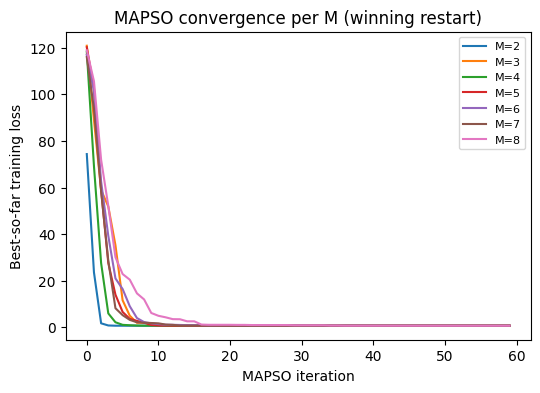

In [14]:
# --- 2.1b -- Diagnostic: did MAPSO plateau before N_EPOCHS_MAPSO? -------------------
# The FSC-inference-MAPSO library has NO built-in early stopping / patience for MAPSO
# (checked its source: the PSO loop in MAPSO.py always runs the full n_iterations, with
# no break-on-no-improvement condition -- by design, since its S3/S4 strategies rely on
# late-stage mutation and "jumping out" to escape local optima, which a naive patience
# check could cut off too early). tinyRNN's RNN training (Section 3) is different: it
# already has real early stopping via 'early_stop_counter' in the base_config.
#
# This curve is where N_EPOCHS_MAPSO in 2.1 comes from: find where the slowest M in your
# sweep flattens, add headroom, cap there. If you change M_CANDIDATES or swap in harder
# data, re-read this plot and retune N_EPOCHS_MAPSO (then FORCE_REFIT / delete the
# affected files in FSC_SWEEP_CACHE_DIR to refit at the new budget).
plt.figure(figsize=(6, 4))
for M in M_CANDIDATES:
    history = fitted_fscs[M].losses_epochs["train"]
    plt.plot(history, label=f"M={M}")
plt.xlabel("MAPSO iteration")
plt.ylabel("Best-so-far training loss")
plt.title("MAPSO convergence per M (winning restart)")
plt.legend(fontsize=8)
plt.show()

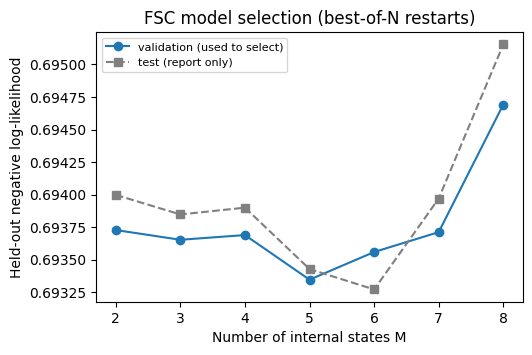

Validation loss is tied across M (all ~0.6933); parsimonious pick within 0.01 -> M* = 2
Per-M held-out TEST loss (report only, NOT used for selection):
   M=2: test = 0.6940
   M=3: test = 0.6938
   M=4: test = 0.6939
   M=5: test = 0.6934
   M=6: test = 0.6933
   M=7: test = 0.6940
   M=8: test = 0.6952


In [15]:
# --- 2.2 -- Model selection: validation is tied across M, so parsimony decides --------
Ms = sorted(fsc_val_losses)

plt.figure(figsize=(5.5, 3.5))
plt.plot(Ms, [fsc_val_losses[m] for m in Ms], "o-", label="validation (used to select)")
plt.plot(Ms, [fsc_test_losses[m] for m in Ms], "s--", c="gray", label="test (report only)")
plt.xlabel("Number of internal states M")
plt.ylabel("Held-out negative log-likelihood")
plt.title("FSC model selection (best-of-N restarts)")
plt.legend(fontsize=8)
plt.show()

# Two things to read off this plot:
#
# 1. WHY EVERY M TIES ON VALIDATION (~0.693). That floor is the cost of the very first trial of
#    each session, which no model can predict (there's no history yet): -log(1/2) = 0.693 nats.
#    Every M>=2 nails everything after that, so validation genuinely cannot separate them. When
#    models are tied on held-out data, parsimony decides: take the SMALLEST M within noise of the
#    best -> M=2, which is correct (WSLS is a 2-state strategy, and 4.2 shows even a larger fitted
#    FSC only ever occupies 2 states).
#
# 2. WHY THE TEST CURVE IS SPIKY (and why restarts did NOT flatten it). This is NOT model error,
#    and NOT a worse model being used on test -- it's the same best-of-N model, and it's
#    near-perfect. The spikes come from the DATA: the behavior follows win-stay-lose-shift almost
#    perfectly, but a tiny fraction of trials break the rule (a "lapse" -- e.g. staying after a
#    loss). In this 1000-session sample there is exactly ONE lapse in ~199k trials, and by luck it
#    landed in the TEST set (zero in validation). A near-deterministic model puts ~100% on the
#    rule-following action, so on that one lapse it eats a huge -log penalty (~73 nats), which
#    alone lifts the mean test loss. No model -- FSC, RNN, or a perfect oracle -- can predict a
#    trial where the subject broke their own rule, which is exactly why RESTARTS LEAVE IT
#    UNCHANGED: restarts fix fitting noise, but this is irreducible noise in the DATA, not the fit.
#    (On harder data where M matters, the same parsimony rule finds the real elbow; widen TOL or
#    use a per-session significance test, like the RNN's paired t-test in 3.3.)
val_min = min(fsc_val_losses.values())
TOL = 0.01
M_STAR = min(m for m in fsc_val_losses if fsc_val_losses[m] <= val_min + TOL)
print(f"Validation loss is tied across M (all ~{val_min:.4f}); parsimonious pick within {TOL} -> M* = {M_STAR}")
print("Per-M held-out TEST loss (report only, NOT used for selection):")
for m in Ms:
    print(f"   M={m}: test = {fsc_test_losses[m]:.4f}")

Loading cached best_fsc from fitted_models/random_init/fsc/best_fsc_M2.pkl


/Users/nawaf/Desktop/Vs code/FSC-Experimentations/.venv/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


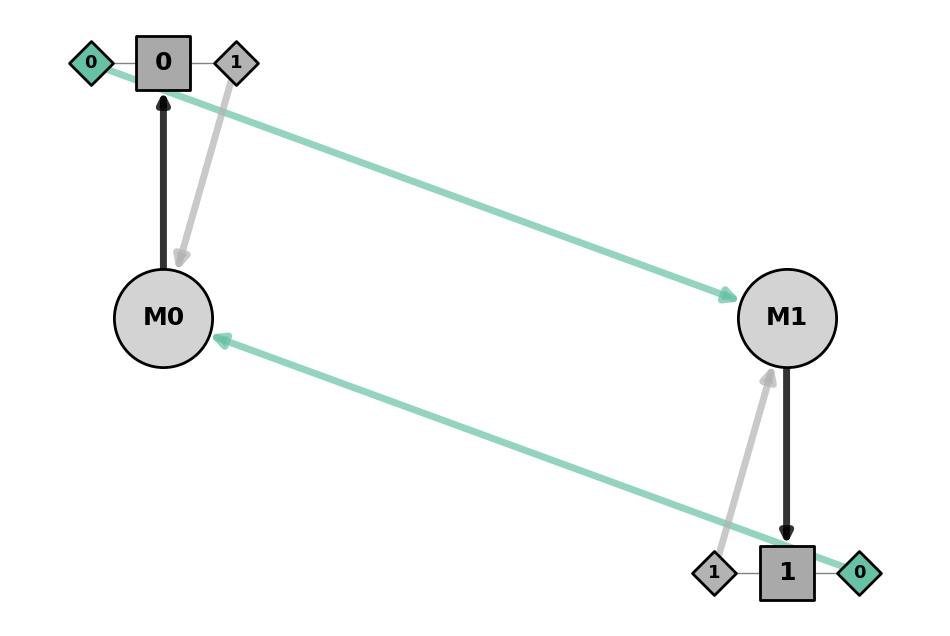

In [16]:
# --- 2.3 -- Refit M* on ALL data (best-of-N) and plot the FSC diagram ----------------
# The final interpretable model uses ALL sessions (no held-out at this stage -- we want the
# best possible fit for the diagram + the Sections 4-9 analysis), so restarts here are ranked by
# their fit loss on all data. Cached like 2.1; FORCE_REFIT_BEST_FSC / deleting the file refits.
FORCE_REFIT_BEST_FSC = False
FSC_SAVE_DIR = f"fitted_models/{DATASET}/fsc/"
best_fsc_cache_path = os.path.join(FSC_SAVE_DIR, f"best_fsc_M{M_STAR}.pkl")

if not FORCE_REFIT_BEST_FSC and os.path.exists(best_fsc_cache_path):
    print(f"Loading cached best_fsc from {best_fsc_cache_path}")
    with open(best_fsc_cache_path, "rb") as f:
        best_fsc = pickle.load(f)
else:
    fsc_all_trajectories = sessions_to_fsc_trajectories(encoded_sessions)
    best_loss_all, best_fsc = None, None
    for r in range(N_RESTARTS):
        cand = fit_one_fsc(M_STAR, seed=FSC_SWEEP_SEED + 10000 + r, trajectories=fsc_all_trajectories)
        L = float(cand.compute_loss(fsc_all_trajectories))
        print(f"   restart {r}: all-data fit loss = {L:.4f}")
        if best_loss_all is None or L < best_loss_all:
            best_loss_all, best_fsc = L, cand
    print(f"   -> kept the restart with all-data fit loss {best_loss_all:.4f}")
    best_fsc.set_mode("generation")
    best_fsc.save(FSC_SAVE_DIR, filename=f"best_fsc_M{M_STAR}.pkl")

best_fsc.set_mode("generation")
obs_colors = plt.cm.Set2(np.linspace(0, 1, Y))
# hide_unused_actions=True drops the action branches with pi(a|m)=0 and the observation
# nodes hanging off them, instead of drawing them with no edges attached.
ax = best_fsc.plot_FSC(observation_node_colors=obs_colors, th_action_probs=1e-3,
                       th_mem_transitions=1e-3, hide_unused_actions=True)
plt.show()


## 3. tinyRNN training

Uses the repo's own `datasets.SimpleDataset` (their built-in generic-data entry
point) and the exact same training call
(`training_experiments.training.behavior_cv_training_config_combination`) used in the
paper's demo script `training_experiments/exp_monkeyV_minimal.py`: nested
cross-validation (outer folds = test sets, inner folds = train/val split) with
multiple random seeds per fold, sweeping `hidden_dim`. Model selection (picking the
smallest hidden size not significantly worse than larger ones) uses the paper's own
`analyzing_experiments.analyzing_perf.select_final_rnn_perf`.

**This will be slow-ish on CPU for real data / larger sweeps.** `outer_splits=5,
inner_splits=4, seed_num=2` (the paper's own minimal-demo defaults) means `5*4*2 =
40` models trained *per hidden_dim value*. Reduce these for a quick check, restore
them for a paper-faithful run.


In [17]:

_use_tinyrnn_path()
os.chdir("tinyRNN")   # training.py assumes it's run from the repo root (path_settings, data_path.json)

from datasets import Dataset
from agents import Agent
from training_experiments.training import behavior_cv_training_config_combination
from analyzing_experiments.analyzing_perf import select_final_rnn_perf


In [18]:
# --- 3.1 -- Build SimpleDataset files (RNN trains on fit+val, HOLDS OUT test) --------
# The RNN must hold out the SAME test set as the FSC, so Section 8 can compare them on
# identical trials. So it trains on fit+val only; test_sessions is untouched until 3.5.
input_format = [
    dict(name="action", one_hot_classes=A),
    dict(name="observation", one_hot_classes=Y),
]
if HAS_REWARD:
    input_format.append(dict(name="reward"))
INPUT_DIM = sum(fmt.get("one_hot_classes", 1) for fmt in input_format)

os.makedirs("files/SimpleDatasetInput", exist_ok=True)
def make_rnn_spec(session_list, filename):
    """Write a SimpleDataset input file for `session_list`, return its behav_data_spec.
    Reused for the training set (3.1), all sessions (3.4), and the test set (3.4)."""
    data = {"action": [s["actions"] for s in session_list],
            "observation": [s["observations"] for s in session_list]}
    if HAS_REWARD:
        data["reward"] = [s["reward"] for s in session_list]
    fpath = f"files/SimpleDatasetInput/{filename}"
    joblib.dump(data, fpath)
    return {"dataset": "Simple", "data": fpath, "input_format": input_format,
            "output_dim": A, "target_name": "action"}

behav_data_spec = make_rnn_spec(train_sessions + val_sessions, "behavior_train.pkl")

# Stamp which dataset this file holds. behavior_train.pkl has ONE fixed name and is overwritten
# every time you switch DATASET, so scripts/train_rnn_parallel.py (the parallel trainer) has no
# other way to tell whether the data on disk matches the --dataset it was told to train. Without
# this it would happily train, say, random_init's data into the exp_det_init/ folder and you'd
# never know. The script refuses to run if this stamp disagrees with its --dataset argument.
with open("files/SimpleDatasetInput/behavior_train.dataset", "w") as _f:
    _f.write(DATASET)
print(f"RNN trains on {len(train_sessions) + len(val_sessions)} sessions (fit+val); "
      f"{len(test_sessions)} test sessions held out.")
print(f"input_dim = {INPUT_DIM}   output_dim (A) = {A}")

RNN trains on 800 sessions (fit+val); 200 test sessions held out.
input_dim = 4   output_dim (A) = 2


In [19]:

# --- 3.2 -- Official nested-CV training sweep over hidden_dim -----------------------
# Caching is already handled by tinyRNN itself: `_train_one_agent` (training_experiments/
# training.py) checks for a 'temp_summary.pkl' in each model's folder under
# MODEL_SAVE_PATH (tinyRNN/files/saved_model/, set in Patch 1) and skips straight to
# loading it if present. So re-running this cell only trains configs that aren't
# finished yet -- it won't redo completed (hidden_dim, outer_fold, inner_fold, seed)
# combinations.
#
# FORCE_RETRAIN_RNN below is the same kind of override toggle as FORCE_REFIT_FSC_SWEEP /
# FORCE_REFIT_BEST_FSC in Section 2: pure notebook-level file deletion using tinyRNN's
# own `path_settings.MODEL_SAVE_PATH`, run *before* calling the library's (unmodified)
# `behavior_cv_training_config_combination`. It does not touch any vendored tinyRNN
# code -- same as the FSC caching, it's just I/O wrapped around the library call.
FORCE_RETRAIN_RNN = False # <-- set to True to wipe this experiment's cache and retrain everything

# L1 penalty on the RNN's recurrent weights. tinyRNN treats l1_weight as a hyperparameter it
# can select over, and it already lives in every model's folder name, so changing it NEVER
# overwrites fits at another l1. We go one step further and give each non-baseline l1 its OWN
# experiment folder + committed archive (exp_<dataset>_l1-<l1>), so you can keep several l1
# values side by side for one dataset and select between them in §3.3 -- change L1_WEIGHT,
# re-run §3.2-§3.4, and the old l1's weights stay put. (The baseline 1e-5 keeps the historical
# name exp_<dataset> so the already-committed fits are still found and reused -- no retrain.)
L1_BASELINE = 1e-5
L1_WEIGHT   = 1e-5     # <-- try e.g. 1e-4 to train + keep a second, separately-selectable l1
EXP_FOLDER  = f"exp_{DATASET}" if L1_WEIGHT == L1_BASELINE else f"exp_{DATASET}_l1-{L1_WEIGHT:g}"

# WHERE THE RNN FITS LIVE, AND WHY THERE ARE TWO COPIES
# -----------------------------------------------------
# tinyRNN reads/writes its fits under tinyRNN/files/saved_model/ (MODEL_SAVE_PATH, set by
# Patch 1). That path is inside the vendored clone, which .gitignore excludes -- so fits left
# there alone are LOCAL ONLY and a fresh clone would retrain the whole sweep from scratch
# (hours). So we keep a committed copy under fitted_models/<dataset>/rnn/, mirroring what the
# FSC side already does with fitted_models/<dataset>/fsc/, and sync the two here:
#   - restore: archive -> live, if the live cache is missing (i.e. right after a clone)
#   - archive: live -> archive, after training, so the fits get committed
import shutil
RNN_LIVE_DIR    = f"files/saved_model/{EXP_FOLDER}"          # cwd is tinyRNN/ in this section
RNN_ARCHIVE_DIR = f"../fitted_models/{DATASET}/rnn/{EXP_FOLDER}"

if FORCE_RETRAIN_RNN:
    # Delete BOTH copies -- deleting only the live one would just be undone by the restore below.
    for _d, _label in ((RNN_LIVE_DIR, "live cache"), (RNN_ARCHIVE_DIR, "committed archive")):
        if os.path.isdir(_d):
            shutil.rmtree(_d)
            print(f"Deleted {_label} at {_d}")
    print("Every hidden_dim/fold/seed combo below will retrain from scratch.")
elif os.path.isdir(RNN_ARCHIVE_DIR) and not os.path.isdir(RNN_LIVE_DIR):
    shutil.copytree(RNN_ARCHIVE_DIR, RNN_LIVE_DIR)
    print(f"Restored committed RNN fits: {RNN_ARCHIVE_DIR} -> {RNN_LIVE_DIR}\n"
          f"(nothing below will retrain; delete that folder or set FORCE_RETRAIN_RNN to redo them)")

# Early stopping: 'early_stop_counter' below IS real patience-based early stopping
# (RNNAgentTrainer.py stops once validation loss hasn't improved for that many epochs),
# using the paper's own default of 200. Unlike MAPSO on the FSC side, this is already
# as fast as the paper's authors made it -- lower it only if you want to trade fidelity
# for speed.
HIDDEN_DIM_CANDIDATES = [1, 2, 3, 4, 5, 6, 7, 8]   # RNN sizes to try (the paper sweeps a range)
# We start at hidden_dim=1 here, but the FSC sweep in 2.1 starts at M=2 -- deliberate, not an
# inconsistency. An FSC with 1 memory state has NO memory: a single state can't be
# history-dependent, so it's a dead baseline we skip. A GRU with 1 hidden unit is different --
# that unit is a CONTINUOUS number updated each trial, so it can still carry information (slide
# toward "play A" vs "play B"). One continuous unit is a real model; one discrete state is not.
# So the two x-axes just start at different points; the FSC-vs-RNN overlay in 3.5 begins at M=2 / H=1.

base_config = {
    ### dataset info
    "dataset": "Simple",
    "behav_format": "tensor",
    "behav_data_spec": behav_data_spec,
    ### model info
    "agent_type": "RNN",
    "rnn_type": "GRU",
    "input_dim": INPUT_DIM,
    "hidden_dim": 2,           # overwritten by config_ranges below
    "output_dim": A,
    "device": "cpu",           # set to "cuda" if you have a GPU
    "output_h0": True,
    "trainable_h0": False,
    "readout_FC": True,
    "one_hot": False,
    ### training info for one model
    "lr": 0.005,
    "l1_weight": L1_WEIGHT,
    "weight_decay": 0,
    "penalized_weight": "rec",
    "max_epoch_num": 2000,        # paper default; lower this for a quick smoke test
    "early_stop_counter": 200,
    ### training info for many models on dataset (paper's own nested-CV settings)
    "outer_splits": 5,
    "inner_splits": 4,
    "seed_num": 2,
    ### additional training info
    "save_model_pass": "minimal",
    "training_diagnose": None,
    "exp_folder": EXP_FOLDER,
}
config_ranges = {
    "rnn_type": ["GRU"],
    "hidden_dim": HIDDEN_DIM_CANDIDATES,
    "readout_FC": [True],
    "l1_weight": [L1_WEIGHT],
}

# HOW THIS CELL RUNS THE SWEEP
# ----------------------------
# n_jobs below is a no-op for RNNs: agent_pool_auto_train (training_experiments/training.py)
# hard-overrides it back to 1 whenever agent_type == 'RNN'. So the library call on its own is
# single-process however large a number you pass. That's upstream's choice, not our bug.
#
# The fits ARE independent across hidden_dim, though. So by default this cell first farms them
# out to one OS process per size (scripts/train_rnn_parallel.py), and only then calls the
# library exactly as before -- by which point every config is already finished, so tinyRNN just
# loads them and skips. Same configs, same folders, same results, ~8x faster on a 10-core Mac.
# Nothing to run by hand: executing the notebook top to bottom gets you the parallel path.
#
# Set PARALLEL_TRAIN = False to go straight through the library, single-process.
#
# DON'T reach for the GPU: these models are tiny (hidden_dim <= 8, input_dim 4), so MPS/CUDA is
# SLOWER than CPU here (measured ~1.4x slower on an M-series Mac -- per-step kernel-launch
# overhead swamps a 4x4 matmul). tinyRNN also runs the net in float64 (RNNAgent calls .double()),
# which Apple's MPS backend cannot do at all. Parallel CPU processes are the real speedup.
PARALLEL_TRAIN = True

if PARALLEL_TRAIN:
    import subprocess
    # cwd is tinyRNN/ here (cell 3.0 chdir'd in); the script resolves the repo root from its own
    # __file__, so it doesn't care where it's called from.
    cmd = [sys.executable, os.path.join("..", "scripts", "train_rnn_parallel.py"),
           "--dataset", DATASET, "--l1", repr(L1_WEIGHT),
           "--dims", *[str(h) for h in HIDDEN_DIM_CANDIDATES]]
    print("Farming the sweep out to one process per hidden_dim:\n  " + " ".join(cmd) + "\n")
    if subprocess.run(cmd).returncode != 0:
        print("\nParallel trainer failed -- falling back to the library's single-process path.\n"
              "(See train_<dataset>_h<dim>.log for why.)")
    else:
        print("\nParallel training finished; the library call below will just load the fits.\n")

behavior_cv_training_config_combination(base_config, config_ranges, n_jobs=8, verbose_level=1)

# Mirror the finished fits out to the committed archive, so a fresh clone (or a teammate)
# doesn't repeat this. Byte-identical when nothing retrained, so git sees no change.
if os.path.isdir(RNN_LIVE_DIR):
    os.makedirs(os.path.dirname(RNN_ARCHIVE_DIR), exist_ok=True)
    if os.path.isdir(RNN_ARCHIVE_DIR):
        shutil.rmtree(RNN_ARCHIVE_DIR)
    shutil.copytree(RNN_LIVE_DIR, RNN_ARCHIVE_DIR)
    _n = sum(len(f) for _, _, f in os.walk(RNN_ARCHIVE_DIR))
    print(f"\nArchived {_n} files to {RNN_ARCHIVE_DIR} (commit these).")

Farming the sweep out to one process per hidden_dim:
  /Users/nawaf/Desktop/Vs code/FSC-Experimentations/.venv/bin/python ../scripts/train_rnn_parallel.py --dataset random_init --l1 0.001 --dims 1 2 3 4 5 6 7 8

dataset=random_init  dims=[1, 2, 3, 4, 5, 6, 7, 8]  l1=0.001  -> 8 parallel processes (10 cores)
Training into exp_random_init_l1-0.001/. Already-finished configs are skipped automatically.

  launch hidden_dim=1  (log: train_random_init_h1.log)
  launch hidden_dim=2  (log: train_random_init_h2.log)
  launch hidden_dim=3  (log: train_random_init_h3.log)
  launch hidden_dim=4  (log: train_random_init_h4.log)
  launch hidden_dim=5  (log: train_random_init_h5.log)
  launch hidden_dim=6  (log: train_random_init_h6.log)
  launch hidden_dim=7  (log: train_random_init_h7.log)
  launch hidden_dim=8  (log: train_random_init_h8.log)
  hidden_dim=1 finished: ok
  hidden_dim=2 finished: ok
  hidden_dim=4 finished: ok
  hidden_dim=3 finished: ok
  hidden_dim=5 finished: ok
  hidden_dim=6 fi

Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 731.48it/s]


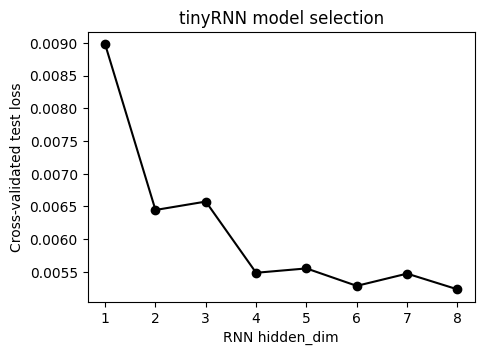

Selected hidden_dim: H* = 6
   hidden_dim  less_than_former  test_loss
0           1                 1   0.008979
1           2                 1   0.006446
2           3                 0   0.006575
3           4                 1   0.005486
4           5                 0   0.005552
5           6                 1   0.005286
6           7                 0   0.005473
7           8                 0   0.005233


In [20]:

# --- 3.3 -- Official model selection: pick the smallest sufficient hidden_dim -------
perf, summary, dim_est = select_final_rnn_perf(EXP_FOLDER, return_dim_est=True, verbose=False)

plt.figure(figsize=(5, 3.5))
plt.plot(dim_est["hidden_dim"], dim_est["test_loss"], "o-", c="k")
plt.xlabel("RNN hidden_dim")
plt.ylabel("Cross-validated test loss")
plt.title("tinyRNN model selection")
plt.show()

# `less_than_former` (from the paper's own select_final_rnn_perf) is 1 at hidden_dim h iff
# h's cross-validated loss is significantly lower (paired t-test over outer folds, p<0.05)
# than EVERY smaller candidate's; it's 0 as soon as some smaller dim is statistically tied.
# H* = the LARGEST hidden_dim with the flag still 1 -- this exactly reproduces the repo's
# own get_dim_from_perf (analyzing_perf.py). Caveat: on near-deterministic data all dims
# are near-perfect, so the t-test can flag a behaviorally-trivial improvement as
# significant (here H*=4 for WSLS, which is really a 1-2 dim strategy). Read H* as an
# upper bound and sanity-check it against the near-flat loss curve.
improved = dim_est.loc[dim_est["less_than_former"] == 1, "hidden_dim"]
H_STAR_AUTO = int(improved.max()) if len(improved) else int(dim_est["hidden_dim"].min())

# --- OPTIONAL: manually override the selected size ----------------------------------
# select_final_rnn_perf can flag a larger size as "best" on a statistically fragile margin --
# e.g. det_init picks H=8 over H=4 at p=0.029 with near-identical loss (see §11). To run the
# whole downstream analysis (§3.4 model load, §4-§8) on a DIFFERENT already-trained size
# instead, set H_STAR_OVERRIDE to that hidden_dim; leave None to use the automatic pick.
# (§6.6b's cross-dataset contrast re-derives each dataset's own H* independently and is not
# affected by this override -- by design, since it reports the official selection.)
H_STAR_OVERRIDE = None      # e.g. 4  ->  force the 4-unit model regardless of the t-test

if H_STAR_OVERRIDE is not None:
    _trained = {int(h) for h in dim_est["hidden_dim"]}
    assert int(H_STAR_OVERRIDE) in _trained, \
        f"no trained model at hidden_dim={H_STAR_OVERRIDE}; trained sizes: {sorted(_trained)}"
    H_STAR = int(H_STAR_OVERRIDE)
    print(f"Auto-selected H* = {H_STAR_AUTO}, but MANUALLY OVERRIDDEN to H* = {H_STAR}")
else:
    H_STAR = H_STAR_AUTO
    print(f"Selected hidden_dim: H* = {H_STAR}")
print(dim_est[["hidden_dim", "less_than_former", "test_loss"]])


In [21]:

# --- 3.4 -- Load the best H*-sized model and extract hidden-state trajectories ------
# Picks, among all (outer_fold, inner_fold, seed) runs at hidden_dim=H_STAR, the one
# with the lowest combined train+val loss (mirrors 'compete_from_keys' logic used
# internally by select_final_rnn_perf for picking a single instance per fold).
h_star_rows = summary[summary["hidden_dim"] == H_STAR].copy() if "hidden_dim" in summary.columns \
    else summary[summary["config"].apply(lambda c: c["hidden_dim"] == H_STAR)].copy()
h_star_rows = h_star_rows.sort_values("trainval_loss")
best_row = h_star_rows.iloc[0]
best_model_path = best_row["model_path"]
print("Loading best model from:", best_model_path)

rnn_config = dict(base_config)
rnn_config.update({"hidden_dim": H_STAR, "seed": 0})
best_agent = Agent("RNN", config=rnn_config)
best_agent.load(str(best_model_path))

# (a) Hidden-state trajectories on ALL sessions (for the Sections 5 and 7 representation analysis).
#     One deterministic forward pass -- given fixed weights the hidden state is fully determined.
spec_all = make_rnn_spec(encoded_sessions, "behavior_all.pkl")
dt_all = Dataset("Simple", behav_data_spec=spec_all).behav_to(rnn_config)
data_all = dt_all.get_behav_data(range(dt_all.batch_size), rnn_config)
rnn_hidden_states = best_agent.forward(data_all, standard_output=True)["internal"]

# (b) Per-trial P(actual action) on the held-out TEST sessions (for the Section 8 comparison).
#     pointwise_loss gives per-trial -log P(actual action); exp(-that) = the probability.
spec_test = make_rnn_spec(test_sessions, "behavior_test.pkl")
dt_test = Dataset("Simple", behav_data_spec=spec_test).behav_to(rnn_config)
data_test = dt_test.get_behav_data(range(dt_test.batch_size), rnn_config)
rnn_test_out = best_agent.forward(data_test, standard_output=True, pointwise_loss=True)
rnn_test_probs = [np.exp(-np.asarray(b)) for b in rnn_test_out["behav_loss"]]

print(f"Hidden states for {len(rnn_hidden_states)} sessions "
      f"(e.g. session 0 shape = {rnn_hidden_states[0].shape}); "
      f"per-trial test probs for {len(rnn_test_probs)} sessions.")
os.chdir("..")   # back to the notebook's working directory


Loading best model from: exp_random_init_l1-0.001/rnn_type-GRU.hidden_dim-6.readout_FC-True.l1_weight-0.001/outerfold4_innerfold2_seed0
Total batch size: 1000
Total batch size: 200
Hidden states for 1000 sessions (e.g. session 0 shape = (201, 6)); per-trial test probs for 200 sessions.


## 4. Reading out both models' internals

Sections 2 and 3 fit each model with its own library. **Everything from here on is our own
code**, and it's organised by *question* rather than by model: each section asks one thing and
answers it for the FSC and the RNN side by side, so the two are always compared on the same
trials with the same convention.

This first section is the plumbing that makes that possible — the per-trial readout of "what is
this model thinking" for each side:

| | FSC | RNN |
|---|---|---|
| the internal state | belief over `M` memory states | hidden vector of `H` numbers |
| where it comes from | forward-filtering (4.1) | one forward pass (3.4) + a by-hand stepper (4.2–4.3) |

One asymmetry to keep in mind, because it recurs: these two are *not* the same kind of object.
The FSC's belief is a probability distribution over named discrete states; the RNN's hidden state
is an unlabelled point in continuous space. §7's probe is what turns that from a problem into a
result.

### 4.1 Reading out the FSC's internal state, trial by trial

In [22]:

def decode_fsc_belief_states(fsc, actions, observations):
    '''Forward-filtering belief b_t(m) = P(memory state = m | actions[:t], observations[:t]),
    for t = 0..T (b_0 = rho, the prior; b_T = belief after the last trial).
    `fsc` must be in 'generation' mode (so get_TMat()/get_rho() return numpy arrays).
    Returns array of shape (T+1, M).'''
    T_mat = fsc.get_TMat()   # shape (Y, M, M, A): axes (obs, prev_mem, next_mem, action)
    rho = np.asarray(fsc.get_rho())
    M = fsc.M

    beliefs = np.zeros((len(actions) + 1, M))
    beliefs[0] = rho
    b = rho.copy()
    for t in range(len(actions)):
        a_t, y_t = int(actions[t]), int(observations[t])
        step = T_mat[y_t, :, :, a_t]     # (prev_mem, next_mem)
        b_new = b @ step                 # sum_m b[m] * step[m, m']
        total = b_new.sum()
        b = b_new / total if total > 0 else np.ones(M) / M   # degenerate fallback
        beliefs[t + 1] = b
    return beliefs

# Restore the FSC import path: after Section 3 put tinyRNN on sys.path, and the FSC's
# generation code lazily JIT-compiles a numba helper from ITS OWN utils.py -- if
# tinyRNN's identically-named utils shadows it at compile time, that import fails.
_use_fsc_path()
best_fsc.set_mode("generation")
fsc_belief_states = [
    decode_fsc_belief_states(best_fsc, s["actions"], s["observations"])
    for s in encoded_sessions
]
print(f"Decoded FSC belief-state trajectories for {len(fsc_belief_states)} sessions, "
      f"e.g. session 0 shape = {fsc_belief_states[0].shape}")

# sanity check: same (T+1) length convention as the RNN's hidden states (output_h0=True)
mismatches = [i for i in range(len(encoded_sessions))
              if fsc_belief_states[i].shape[0] != rnn_hidden_states[i].shape[0]]
print("Sessions with mismatched lengths (should be empty):", mismatches)


Decoded FSC belief-state trajectories for 1000 sessions, e.g. session 0 shape = (201, 2)
Sessions with mismatched lengths (should be empty): []


In [23]:
# --- 4.2 -- Pull the trained GRU weights out into plain numpy -------------------------
# Why by hand? Two things we need later are simply not exposed by the library:
#   (a) the update / reset / new GATE values at each trial (§9.1) -- nn.GRU computes them
#       internally and returns only the resulting hidden state; and
#   (b) AUTOREGRESSIVE generation (§6.2) -- feeding the RNN its OWN sampled action back in
#       as the next input. RNNAgent.forward() is teacher-forced: it always consumes the
#       real action, so it can't generate.
# Both need a single-step function we control. So we re-implement one GRU step in numpy
# from the trained weights, and verify in 4.3 that it matches the library exactly.
#
# WHICH GRU: network_models.py uses torch's OFFICIAL nn.GRU when rnn_type='GRU' (the custom
# GRUCell in custom_rnn_layers.py is only used for SGRU/MIGRU/PNR/...), so we follow nn.GRU's
# equations and its (reset, update, new) chunk order.
#
# H_STAR (from 3.3) is the model the main FSC-vs-RNN comparison uses. H_TO_COMPARE is a
# separate SIZE SUB-STUDY -- the professor asked what an H=2 RNN does differently from H=4 --
# and it runs through §5.3, §6 and §9 alongside the main line.
H_TO_COMPARE = [2, 4, 8]

def extract_gru_params(agent):
    """Trained torch weights -> plain numpy. nn.GRU packs the three gates into a single
    matrix, stacked along axis 0 in the order (reset, update, new)."""
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(),
            "H": net.hidden_dim}

_use_tinyrnn_path()
os.chdir("tinyRNN")          # MODEL_SAVE_PATH is relative, so loading needs repo-root as cwd
from agents import Agent
from datasets import Dataset

rnn_params_folds = {}        # {H: [params, ...]} -- every run at that size, best loss first
rnn_params = {}              # {H: params}        -- just the best run at that size
rnn_ref_hidden = {}          # {H: [...]}         -- a library forward pass, to check 4.3 against

for H in H_TO_COMPARE:
    rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
    cfg = dict(base_config); cfg.update({"hidden_dim": H, "seed": 0})
    plist = []
    for _, r in rows.iterrows():
        ag = Agent("RNN", config=cfg)
        ag.load(str(r["model_path"]))
        plist.append(extract_gru_params(ag))
    rnn_params_folds[H] = plist
    rnn_params[H] = plist[0]

    ag = Agent("RNN", config=cfg)
    ag.load(str(rows.iloc[0]["model_path"]))
    spec_chk = make_rnn_spec(encoded_sessions[:3], "behavior_check.pkl")
    dt_chk = Dataset("Simple", behav_data_spec=spec_chk).behav_to(cfg)
    data_chk = dt_chk.get_behav_data(range(dt_chk.batch_size), cfg)
    rnn_ref_hidden[H] = ag.forward(data_chk, standard_output=True)["internal"]
    print(f"H={H}: {len(plist)} runs, best = {rows.iloc[0]['model_path']}")

os.chdir("..")
_use_fsc_path()              # everything downstream is pure numpy + the FSC

Total batch size: 3
H=2: 5 runs, best = exp_random_init_l1-0.001/rnn_type-GRU.hidden_dim-2.readout_FC-True.l1_weight-0.001/outerfold2_innerfold1_seed0
Total batch size: 3
H=4: 5 runs, best = exp_random_init_l1-0.001/rnn_type-GRU.hidden_dim-4.readout_FC-True.l1_weight-0.001/outerfold2_innerfold0_seed0
Total batch size: 3
H=8: 5 runs, best = exp_random_init_l1-0.001/rnn_type-GRU.hidden_dim-8.readout_FC-True.l1_weight-0.001/outerfold2_innerfold0_seed0


In [24]:
# --- 4.3 -- One GRU step, written out, with the gates exposed ------------------------
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def _softmax(z):
    z = np.asarray(z, dtype=float); z = z - z.max()
    e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """One step of torch's nn.GRU, spelled out so the gates are visible:
         r = sigmoid(W_ir x + b_ir + W_hr h + b_hr)        'reset'
         z = sigmoid(W_iz x + b_iz + W_hz h + b_hz)        'update'
         n = tanh(W_in x + b_in + r * (W_hn h + b_hn))     'new'
         h' = (1 - z) * n + z * h
    Returns (new hidden state, dict of the three gate vectors, each length H).
    How to read them: z ~ 1 => hold the old state, z ~ 0 => overwrite it with n.
    r gates how much of the old state is allowed into the proposal n."""
    H = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r = _sigmoid(gi[:H]    + gh[:H])
    z = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_encode_input(a, y):
    """One trial's input vector: one-hot(action) then one-hot(observation) -- exactly the
    order §3.1's `input_format` concatenates them in."""
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0
    return x

def rnn_action_probs(h, P):
    """The readout: P(action | hidden state) = softmax(Linear(h))."""
    return _softmax(h @ P["lin_W"].T + P["lin_b"])

# --- verify the by-hand step against the library's own forward pass -------------------
# h0 is all-zeros because §3.2 sets trainable_h0=False (network_models.py then fixes
# h0 = torch.zeros). If this check ever fails, nothing below can be trusted.
print("Max |by-hand - library| over a full session's hidden states:")
for H in H_TO_COMPARE:
    P = rnn_params[H]
    s = encoded_sessions[0]
    h = np.zeros(P["H"]); hs = [h.copy()]
    for t in range(len(s["actions"])):
        h, _ = gru_step(h, rnn_encode_input(int(s["actions"][t]), int(s["observations"][t])), P)
        hs.append(h.copy())
    diff = np.abs(np.array(hs) - rnn_ref_hidden[H][0]).max()
    print(f"   H={H}:  {diff:.2e}   {'OK' if diff < 1e-9 else 'MISMATCH -- investigate'}")

Max |by-hand - library| over a full session's hidden states:
   H=2:  5.83e-16   OK
   H=4:  8.88e-16   OK
   H=8:  3.33e-16   OK


In [25]:
# --- 4.4 -- Trial-by-trial alignment: raw data, side by side, for one example session ------
# This TABLE is just an illustrative peek -- one session, so you can eyeball the FSC's belief and
# the RNN's hidden numbers changing together trial by trial. The table itself isn't used
# downstream, but the arrays behind it (fsc_belief_states, rnn_hidden_states) ARE the raw material
# for the occupancy check (5.1), the PCA (5.2), and the linear probe (Section 7).
example_idx = 0
acts = encoded_sessions[example_idx]["actions"]
obs = encoded_sessions[example_idx]["observations"]

alignment_table = pd.DataFrame({
    "trial": np.arange(len(rnn_hidden_states[example_idx])),
    "action": np.concatenate([[np.nan], acts]),
    "observation": np.concatenate([[np.nan], obs]),
    **{f"fsc_belief_m{m}": fsc_belief_states[example_idx][:, m] for m in range(M_STAR)},
    **{f"rnn_hidden_h{h}": rnn_hidden_states[example_idx][:, h] for h in range(H_STAR)},
})
alignment_table

,trial,action,observation,fsc_belief_m0,fsc_belief_m1,rnn_hidden_h0,rnn_hidden_h1,rnn_hidden_h2,rnn_hidden_h3,rnn_hidden_h4,rnn_hidden_h5
0,0,NaN,NaN,4.880689e-01,5.119311e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,1.0,0.0,1.000000e+00,1.910276e-09,-0.747960,-0.515563,-0.763427,-0.411996,-0.184234,0.498370
2,2,0.0,1.0,1.000000e+00,4.323099e-14,-0.779578,-0.550578,-0.185623,-0.595778,-0.317986,0.458537
3,3,0.0,1.0,1.000000e+00,4.323041e-14,-0.783974,-0.565049,-0.172766,-0.677953,-0.415310,0.420242
4,4,0.0,1.0,1.000000e+00,4.323041e-14,-0.784692,-0.572229,-0.172351,-0.714619,-0.486116,0.383438
...,...,...,...,...,...,...,...,...,...,...,...
196,196,1.0,0.0,1.000000e+00,1.899204e-09,-0.870583,-0.556697,-0.774691,-0.744103,-0.675230,0.764759
197,197,0.0,0.0,9.627837e-10,1.000000e+00,-0.984247,0.136349,-0.606428,-0.744025,-0.675149,-0.791080
198,198,1.0,0.0,1.000000e+00,1.899204e-09,-0.871006,-0.557053,-0.774963,-0.744033,-0.675259,0.773642
199,199,0.0,1.0,1.000000e+00,4.323099e-14,-0.797398,-0.551110,-0.185024,-0.744021,-0.675228,0.723921


## 5. How much memory does each model use, and what does it encode?

Both models were fit at a size the selectors chose (`M*` and `H*`), and both selectors are known
to over-pick on near-deterministic data. So the question is the same for each: **of the capacity
it was given, how much does it actually use — and what does the used part represent?**

The two get the same treatment, in the same order, with the same labels
(`combo_labels` = the previous `(action, outcome)` pair):

| | FSC (5.1) | RNN (5.2, 5.3) |
|---|---|---|
| how much is used | occupancy of each memory state | PCA spectrum / participation ratio |
| what it encodes | state × `(prev action, prev outcome)` crosstab | k-means clusters × the same crosstab |

### 5.1 How much of the FSC's memory does it actually use?
`M*` states were fit, but a model can be fit with M states and still behave, in practice,
like it only needs a handful. We check directly: take the most-likely state (argmax of
the belief) at each trial across every session, and see how much of the probability mass
each state actually carries -- then check what those heavily-used states correspond to in
the real (previous action, previous outcome) history.

> **Caveat:** "occupancy" below only counts a state when it's the single most-likely one
> (the argmax). But the FSC actually uses the FULL belief when predicting an action, not just
> the top guess -- so a state that's never in first place but consistently sits at, say, 30%
> could still be shaping every prediction. Low occupancy means "rarely the top guess", not
> necessarily "doing nothing". (Doesn't change anything here -- M*=2 and both states are heavily
> used with no overlap -- but keep it in mind for a bigger M.)

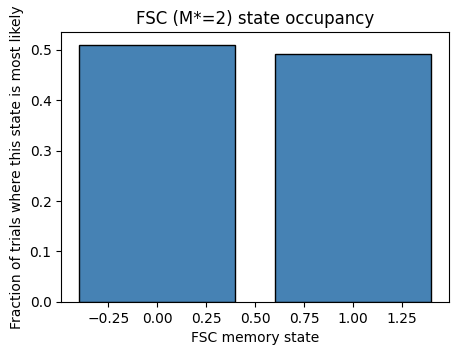

States with >1% occupancy: 2 out of 2

Dominant FSC state vs. (previous action, previous outcome) -- rows = FSC state:
       acted 0, lost  acted 0, won  acted 1, lost  acted 1, won
row_0                                                          
0                  0         59985          41887             0
1              41860             0              0         55268


In [26]:
# --- 5.1 -- FSC memory occupancy, and what each occupied state corresponds to ---------
# "Decide-time" convention (matches the loss / RNN section below): belief_states[i][t] is
# the belief used to choose action[t], built from history strictly before t. We drop the
# LAST belief per session (the posterior after the final trial) since it was never used to
# make a prediction -- exactly like the RNN's own loss drops its last score.
combo_labels_list = []
for s in encoded_sessions:
    a, o = s["actions"], s["observations"]
    T = len(a)
    labels = [-1] + [a[t] * Y + o[t] for t in range(T - 1)]   # -1 = trial 0, no previous trial
    combo_labels_list.append(np.array(labels))
combo_labels = np.concatenate(combo_labels_list)
combo_names = {0: "acted 0, lost", 1: "acted 0, won", 2: "acted 1, lost", 3: "acted 1, won"}

decide_time_fsc = np.concatenate([b[:-1] for b in fsc_belief_states], axis=0)
hard_states = decide_time_fsc.argmax(axis=1)
occupancy = np.bincount(hard_states, minlength=M_STAR) / len(hard_states)

# Bar chart: one bar per memory state. The x-axis positions are just WHERE each bar sits
# (state 0 centered at x=0, state 1 at x=1) -- not data. The information is the bar HEIGHTS:
# the fraction of trials where that state is the most likely one.
plt.figure(figsize=(5, 3.5))
plt.bar(range(M_STAR), occupancy, color="steelblue", edgecolor="k")
plt.xlabel("FSC memory state"); plt.ylabel("Fraction of trials where this state is most likely")
plt.title(f"FSC (M*={M_STAR}) state occupancy")
plt.show()

used = (occupancy > 0.01).sum()
print(f"States with >1% occupancy: {used} out of {M_STAR}\n")

mask = combo_labels != -1
ct = pd.crosstab(hard_states[mask], combo_labels[mask])
ct.columns = [combo_names[c] for c in ct.columns]
print("Dominant FSC state vs. (previous action, previous outcome) -- rows = FSC state:")
print(ct)

### 5.2 The RNN's hidden-state geometry, and what it encodes

The RNN's internal state is a continuous **H**-dimensional vector per trial -- a list of H numbers,
with no built-in labels, unlike the FSC's discrete states. Every point we're about to plot is one
trial's hidden vector, taken from the single forward pass in 3.4 (one point per trial of every
session -- no new run). *For this dataset: H = 5, and N ≈ 199,000 points.*

**The problem:** we can't look at an H-dimensional cloud of points directly. So we flatten it to
2D with **PCA (Principal Component Analysis)**, purely to *see its shape*.

**What PCA actually does** (this is the "what are the two variables?" question). It does **not**
pick two of the hidden units. It invents two brand-new axes out of the data:

- **PC1** = the single direction through the cloud along which the points are *most spread out*.
- **PC2** = the direction of the *next*-most spread, at a right angle to PC1.

Each new axis is a fixed weighted mix of the original H hidden units
(e.g. `PC1 = 0.41·h₁ − 0.68·h₂ + …`); the weights are computed as the top two eigenvectors of the
data's covariance matrix. So the two plot axes are simply the two directions that preserve as much
of the cloud's spread as possible when we squash H-D down to 2-D. They carry no built-in meaning --
we read meaning into them *afterward*, by coloring.

We color each point by the (previous action, previous outcome) of the immediately preceding trial
(the `combo_labels` from 5.1) -- for WSLS that is the only thing the rule depends on. If the colors
fall into clean, separated regions, the black-box RNN has organized its state space around the same
few history-contexts the FSC represents explicitly.

**Important:** the k-means "purity" printed below clusters the **raw H-D hidden state, not the 2-D
PCA picture**, and it does *not* use the color labels to form the clusters (the labels only score
them afterward). So it's an objective check -- not an artifact of the projection or of the coloring.


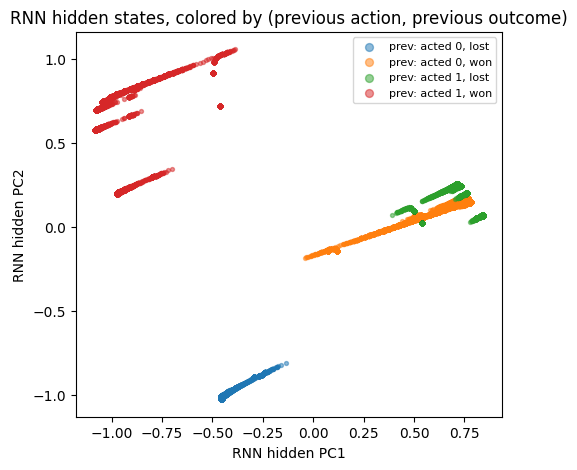

k-means (k=4) on the raw 6-d hidden state vs. (prev action, prev outcome): 100.0% purity
       acted 0, lost  acted 0, won  acted 1, lost  acted 1, won
row_0                                                          
0                  0             0              0         55268
1                  0         59985              0             0
2              41860             0              0             0
3                  0             0          41887             0


In [27]:
from sklearn.decomposition import PCA
# --- 5.2 -- The RNN's hidden states, colored by (previous action, previous outcome) ---
# Same decide-time convention as 5.1: drop the last hidden state per session (index T),
# since RNNAgent.py's own loss drops it too (it was never used to predict anything).
decide_time_rnn = np.concatenate([h[:-1] for h in rnn_hidden_states], axis=0)

# NumPy on Apple Silicon (Accelerate BLAS backend) is known to throw spurious
# divide-by-zero/overflow RuntimeWarnings on matmul for some array shapes, even when
# every value involved is finite and correct (verified: no NaN/Inf in decide_time_rnn,
# and the clustering result below is exactly right) -- so we suppress just this class
# of warning rather than leave unexplained red text next to a correct result.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    if decide_time_rnn.shape[1] > 2:
        coords_labeled = PCA(n_components=2).fit_transform(decide_time_rnn)
    else:
        coords_labeled = np.pad(decide_time_rnn, ((0, 0), (0, 2 - decide_time_rnn.shape[1])))

if decide_time_rnn.shape[1] > 2:
    xlabel2, ylabel2 = "RNN hidden PC1", "RNN hidden PC2"
else:
    xlabel2, ylabel2 = "RNN hidden dim 1", "RNN hidden dim 2"

mask = combo_labels != -1
plt.figure(figsize=(5.5, 5))
for combo_val, name in combo_names.items():
    sel = mask & (combo_labels == combo_val)
    plt.scatter(coords_labeled[sel, 0], coords_labeled[sel, 1], s=8, alpha=0.5, label=f"prev: {name}")
plt.xlabel(xlabel2); plt.ylabel(ylabel2)
plt.legend(fontsize=8, markerscale=2)
plt.title("RNN hidden states, colored by (previous action, previous outcome)")
plt.show()

# Quantify the visual impression: cluster the RAW hidden state (not the 2D projection) and
# check how purely each cluster maps onto one (previous action, previous outcome) combo.
from sklearn.cluster import KMeans
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(decide_time_rnn[mask])
ct_rnn = pd.crosstab(km.labels_, combo_labels[mask])
ct_rnn.columns = [combo_names[c] for c in ct_rnn.columns]
purity = ct_rnn.max(axis=1).sum() / ct_rnn.values.sum()
print(f"k-means (k=4) on the raw {H_STAR}-d hidden state vs. (prev action, prev outcome): "
      f"{purity*100:.1f}% purity")
print(ct_rnn)

### 5.2b Same picture, any RNN size
The cell above uses the selected `H*`. This repeats the PCA and the k-means purity for every size in `PCA_SIZES` (default `H_TO_COMPARE`), rebuilt from each model\'s own weights — so you can see how the geometry fills out as units are added.

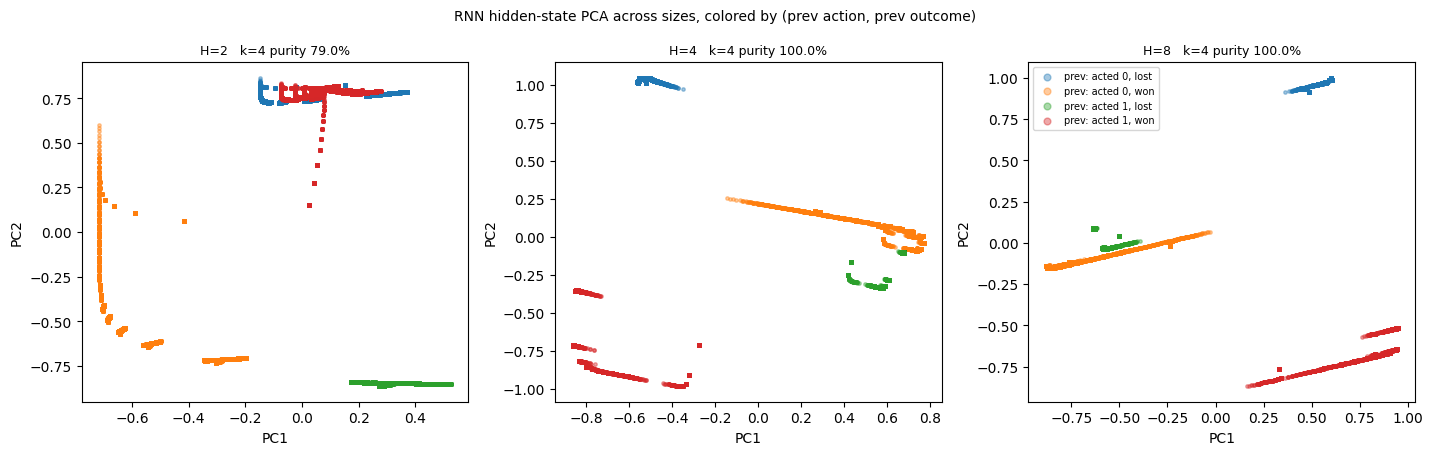

In [28]:
# --- 5.2b -- The same PCA + purity, for ANY trained RNN size ------------------------
# 5.2 above shows only the selected size H*. Set PCA_SIZES to eyeball others. We rebuild each
# size\'s decide-time hidden states from its own weights (gru_step, verified identical to the
# library in §4.3), so the coloring by combo_labels stays aligned -- no re-fitting, just replay.
PCA_SIZES = H_TO_COMPARE          # e.g. [2, 4, 8]; edit freely to any subset of rnn_params keys

def _decide_time_hidden(H):
    """Decide-time hidden states for the H-sized model over ALL encoded_sessions, concatenated
    and aligned with combo_labels (one state per trial, i.e. each session\'s last state dropped)."""
    P = rnn_params[H]; chunks = []
    for s in encoded_sessions:
        h = np.zeros(P["H"]); hs = []
        for t_ in range(len(s["actions"])):
            hs.append(h.copy())
            h, _ = gru_step(h, rnn_encode_input(int(s["actions"][t_]), int(s["observations"][t_])), P)
        chunks.append(np.array(hs))
    return np.concatenate(chunks, axis=0)

fig, axes = plt.subplots(1, len(PCA_SIZES), figsize=(4.8 * len(PCA_SIZES), 4.6), squeeze=False)
for ax, H in zip(axes[0], PCA_SIZES):
    X = _decide_time_hidden(H)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        coords = (PCA(n_components=2).fit_transform(X) if X.shape[1] > 2
                  else np.pad(X, ((0, 0), (0, 2 - X.shape[1]))))
        km_H = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X[mask])
    for combo_val, name in combo_names.items():
        sel = mask & (combo_labels == combo_val)
        ax.scatter(coords[sel, 0], coords[sel, 1], s=6, alpha=0.4, label=f"prev: {name}")
    ct = pd.crosstab(km_H.labels_, combo_labels[mask])
    purity = ct.max(axis=1).sum() / ct.values.sum()
    star = "  (= H*)" if H == H_STAR else ""
    ax.set_title(f"H={H}{star}   k=4 purity {purity*100:.1f}%", fontsize=9)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
axes[0][-1].legend(fontsize=7, markerscale=2, loc="best")
fig.suptitle("RNN hidden-state PCA across sizes, colored by (prev action, prev outcome)", fontsize=10)
plt.tight_layout(); plt.show()

### 5.3 …and how many dimensions does each RNN size really use?

5.2 looked at the selected model (`H*`). The same two summaries, applied to the H=2 vs H=4
sub-study, are what answer *"is anything different in the dynamics of the hidden units?"*:

- **`corr(unit, action)`** — how strongly each hidden unit tracks the action about to be taken.
- **participation ratio** of the PCA variance spectrum — how many dimensions the hidden state
  *actually* uses: 1 means all the variance sits on a single axis, H means it's spread evenly.

In [29]:
# --- 5.3 -- How many hidden dimensions does each RNN really use? ---------------------
for H in H_TO_COMPARE:
    P = rnn_params[H]
    hs, acts = [], []
    for s in test_sessions[:50]:                    # 50 sessions is plenty for these summaries
        h = np.zeros(P["H"])
        for t in range(len(s["actions"])):
            hs.append(h.copy()); acts.append(int(s["actions"][t]))
            h, _ = gru_step(h, rnn_encode_input(int(s["actions"][t]), int(s["observations"][t])), P)
    hs = np.array(hs); acts = np.array(acts)
    corr = [np.corrcoef(hs[:, u], acts)[0, 1] for u in range(H)]
    sv = np.linalg.svd(hs - hs.mean(0), compute_uv=False)
    var = sv**2 / (sv**2).sum()
    pr = var.sum()**2 / (var**2).sum()              # participation ratio
    print(f"H={H}   ({len(hs):,} trials)")
    print(f"   corr(unit, action about to be taken): {np.round(corr, 3)}")
    print(f"   PCA variance per axis:                {np.round(var, 3)}")
    print(f"   participation ratio (effective dims): {pr:.2f}  of {H}\n")

H=2   (10,000 trials)
   corr(unit, action about to be taken): [0.402 0.975]
   PCA variance per axis:                [0.816 0.184]
   participation ratio (effective dims): 1.43  of 2

H=4   (10,000 trials)
   corr(unit, action about to be taken): [-0.416 -0.965  0.365 -0.497]
   PCA variance per axis:                [0.479 0.363 0.154 0.004]
   participation ratio (effective dims): 2.60  of 4

H=8   (10,000 trials)
   corr(unit, action about to be taken): [-0.412 -0.104 -0.266  0.007  0.009  0.978 -0.513  0.011]
   PCA variance per axis:                [0.531 0.293 0.159 0.013 0.002 0.001 0.    0.   ]
   participation ratio (effective dims): 2.54  of 8



> **Caveat:** participation ratio measures how much the hidden state *moves* along each
> direction -- not how useful that direction is. A dimension can barely move and still carry a
> perfect signal (e.g. always +0.01 after a win, -0.01 after a loss). So "the RNN uses ~2
> dimensions" means its motion is squeezed into ~2 directions -- **not** that the other
> dimensions do nothing. Whether they actually matter is a question PR can't answer.

### 5.4 Which hidden units actually contribute to the output?
The direct test of whether a unit is used: **freeze it** — pin its activation to its average value on
every trial, leaving every other unit running normally — and replay the held-out sessions. If the
predictions don't change, that unit wasn't contributing to the output. Doing this one unit at a time
gives a per-unit "is it doing anything" score, which participation ratio (§5.3) can't tell you.

Freezing pins the unit's *state* to a constant; it touches no weight and no bias, so the unit still
adds its mean offset to the readout — we're testing whether its trial-to-trial **movement** matters.

Caveat: this is a leave-one-out test, so it under-reports *redundant* units — if two units carry the
same signal, freezing either alone costs nothing (the other covers for it), even though the
information is clearly there. A near-zero cost means "not needed given the others", not "encodes nothing".

In [30]:
# --- 5.4 -- Which hidden units actually contribute to the output? (per-unit ablation) ------
# The direct test of "is this unit used": freeze ONE unit at a time -- pin its activation to its
# average value on every trial, leave all other units live -- and replay the same held-out sessions.
# If the RNN's predictions don't change, that unit wasn't contributing to the output.
#
# This pins the unit's STATE to a constant; it does NOT touch any weight or bias, so the unit still
# adds its mean offset to the readout -- the test is whether its trial-to-trial MOVEMENT matters.
# (To disable a unit completely instead, pin it to 0 rather than its mean below.)

def rnn_unit_stats(H, sessions):
    """Replay `sessions` teacher-forced and return each unit's (mean activation, variance)."""
    P = rnn_params[H]
    hs = []
    for s in sessions:
        h = np.zeros(P["H"])
        for t in range(len(s["actions"])):
            hs.append(h.copy())
            h, _ = gru_step(h, rnn_encode_input(int(s["actions"][t]), int(s["observations"][t])), P)
    hs = np.array(hs)
    return hs.mean(axis=0), hs.var(axis=0)

def rnn_nll_freeze_units(H, mean, frozen, sessions):
    """NLL when the units in `frozen` are pinned to their per-unit average each trial (every other
    unit runs normally). frozen == [] -> the untouched full model."""
    P = rnn_params[H]
    frozen = np.array(sorted(int(u) for u in frozen), dtype=int)
    probs = []
    for s in sessions:
        h = np.zeros(H)
        for t in range(len(s["actions"])):
            a_t = int(s["actions"][t])
            probs.append(rnn_action_probs(h, P)[a_t])
            h, _ = gru_step(h, rnn_encode_input(a_t, int(s["observations"][t])), P)
            if len(frozen):
                h[frozen] = mean[frozen]                  # <- pin to 0 instead of mean to fully disable
    return -np.log(np.clip(np.array(probs), 1e-300, 1.0)).mean()

for H in H_TO_COMPARE:
    mean, var = rnn_unit_stats(H, test_sessions)
    full = rnn_nll_freeze_units(H, mean, [], test_sessions)          # nothing frozen: the real model
    print(f"H={H}   full model NLL = {full:.5f}")
    for u in range(H):
        nll = rnn_nll_freeze_units(H, mean, [u], test_sessions)      # freeze ONLY unit u
        verdict = "contributes" if nll - full > 1e-4 else "~ unused (given the others)"
        print(f"   freeze unit {u} (var={var[u]:.4f}):  NLL={nll:.5f}   "
              f"(worse by {nll - full:+.5f})   -> {verdict}")
    print()

H=2   full model NLL = 0.00648
   freeze unit 0 (var=0.1253):  NLL=0.02606   (worse by +0.01959)   -> contributes
   freeze unit 1 (var=0.5425):  NLL=0.67907   (worse by +0.67260)   -> contributes

H=4   full model NLL = 0.00539
   freeze unit 0 (var=0.2693):  NLL=0.03133   (worse by +0.02594)   -> contributes
   freeze unit 1 (var=0.3746):  NLL=0.15390   (worse by +0.14851)   -> contributes
   freeze unit 2 (var=0.1810):  NLL=0.01801   (worse by +0.01262)   -> contributes
   freeze unit 3 (var=0.1731):  NLL=0.01372   (worse by +0.00833)   -> contributes

H=8   full model NLL = 0.00510
   freeze unit 0 (var=0.2657):  NLL=0.01595   (worse by +0.01085)   -> contributes
   freeze unit 1 (var=0.0063):  NLL=0.00536   (worse by +0.00026)   -> contributes
   freeze unit 2 (var=0.1217):  NLL=0.00774   (worse by +0.00263)   -> contributes
   freeze unit 3 (var=0.0049):  NLL=0.00513   (worse by +0.00002)   -> ~ unused (given the others)
   freeze unit 4 (var=0.0032):  NLL=0.00510   (worse by -0.

## 6. Does each model reproduce the behavior when it generates?

Everything so far *reads* the models while replaying real behavior through them. This section
lets each model **drive** — and then compares them on the one object that makes their strategies
directly readable side by side.

The trick, for both models, is the same: feed the **real observation sequence** and let the model
choose its own actions. No environment model is needed, and both are probed identically. What
this asks is a question purely about the **policy** — *"given the outcome you just saw, do you
stay or shift?"* — which is exactly the `p(stay|win)` / `p(change|lose)` check.

| | |
|---|---|
| 6.1 | FSC generates → stay/shift rates |
| 6.2 | RNN generates → stay/shift rates *(the same check, same convention)* |
| 6.3 | what the RNN's hidden state and actions look like over time |
| 6.4 | **the head-to-head:** $P(A_t \mid A_{t-1}, Y_{t-1})$ for the data, the FSC, and each RNN |
| 6.5 | the first action — where H=2 and H=4 disagree |

The caveat that applies to both: the real outcomes were produced in response to the *real*
actions, so once a model's choices diverge the outcome sequence is off-policy for it. Harmless
here — the WSLS rule only reads the outcome, never the counterfactual.

### 6.1 Does the fitted FSC reproduce win-stay/lose-shift when it generates?
Everything above inspects the FSC's *internal* state. The authors' own demos (e.g.
MouseBandits) validate a fitted FSC a different way: **generate** synthetic behavior from
it and compare to the real thing. We do the same, without needing a custom environment
model -- feed the FSC the REAL observation sequences from held-out sessions via
`generate_single_trajectory(observations=...)`, let it generate its OWN actions in
response, and compare the resulting stay/shift rates to the real data's.

In [31]:
# --- 6.1 -- Generate behavior from the fitted FSC and compare to the real data ----------
# Restore the FSC import path: after Section 3 put tinyRNN on sys.path, and the FSC's
# generation code lazily JIT-compiles a numba helper from ITS OWN utils.py -- if
# tinyRNN's identically-named utils shadows it at compile time, that import fails.
_use_fsc_path()
best_fsc.set_mode("generation")

def stay_rates(actions, observations):
    actions = np.asarray(actions); observations = np.asarray(observations)
    stay = (actions[1:] == actions[:-1]).astype(float)
    prev_obs = observations[:-1]
    p_win = stay[prev_obs == 1].mean() if (prev_obs == 1).any() else np.nan
    p_lose = stay[prev_obs == 0].mean() if (prev_obs == 0).any() else np.nan
    return p_win, p_lose

real_rates, gen_rates = [], []
for s in test_sessions:
    o = s["observations"]
    real_rates.append(stay_rates(s["actions"], o))
    generated = best_fsc.generate_single_trajectory(observations=o)
    gen_rates.append(stay_rates(generated["actions"], o))
real_rates = np.array(real_rates); gen_rates = np.array(gen_rates)

print("                        real data   FSC-generated")
print(f"P(stay | previous WIN):   {np.nanmean(real_rates[:,0]):.4f}       {np.nanmean(gen_rates[:,0]):.4f}")
print(f"P(stay | previous LOSE):  {np.nanmean(real_rates[:,1]):.4f}       {np.nanmean(gen_rates[:,1]):.4f}")
print("\nThe fitted FSC, when driven by the real held-out observation sequences, reproduces\n"
      "the win-stay/lose-shift pattern almost exactly -- direct evidence the fitted internal\n"
      "dynamics correspond to the actual behavioral rule, not just a loss number.")

                        real data   FSC-generated
P(stay | previous WIN):   1.0000       1.0000
P(stay | previous LOSE):  0.0000       0.0000

The fitted FSC, when driven by the real held-out observation sequences, reproduces
the win-stay/lose-shift pattern almost exactly -- direct evidence the fitted internal
dynamics correspond to the actual behavioral rule, not just a loss number.


### 6.2 Generating behavior from the RNN

To make the RNN *generate*, we feed it a real observation sequence and let it pick its own
actions, feeding each sampled action back in as the next input. This is exactly the trick
§6.1 already uses for the FSC (`generate_single_trajectory(observations=...)`): borrow the
real outcome sequence instead of simulating an environment, so no environment model is
needed and both models are probed identically.

What this asks is a question purely about the **policy** — *"given the outcome you just saw,
do you stay or shift?"* — which is precisely the professor's `p(stay|win)` / `p(change|lose)`
check. The caveat is that the real outcomes were produced in response to the *real* actions,
so once the RNN's choices diverge the outcome sequence is off-policy for it. That's harmless
here: the WSLS rule only reads the outcome, never the counterfactual.

In [32]:
# --- 6.2 -- Generate trajectories FROM the RNN --------------------------------------
def generate_rnn_trajectory(P, observations, rng, greedy=False):
    """Drive the RNN with an observation sequence and let it choose its OWN actions,
    feeding each one back in as the next input. Records the hidden state and all three
    gates at every step so 6.4/6.5 can plot them."""
    h = np.zeros(P["H"]); T = len(observations)
    out = {"actions": np.zeros(T, dtype=int),
           "hidden":  np.zeros((T + 1, P["H"])),
           "probs":   np.zeros((T, A)),
           **{g: np.zeros((T, P["H"])) for g in ("reset", "update", "new")}}
    out["hidden"][0] = h
    for t in range(T):
        p = rnn_action_probs(h, P)
        a = int(p.argmax()) if greedy else int(rng.choice(A, p=p))
        out["probs"][t] = p; out["actions"][t] = a
        h, gates = gru_step(h, rnn_encode_input(a, int(observations[t])), P)
        out["hidden"][t + 1] = h
        for g in ("reset", "update", "new"):
            out[g][t] = gates[g]
    return out

# `stay_rates` is reused from §6.1 -- same definition, same convention.
# All four conditional rates, not just the two WSLS "predicts": stay|win and shift|lose are
# what the rule expects; shift|win and stay|lose are the rule's ERRORS, and are worth seeing
# directly rather than inferring as "1 minus the other number".
print("Generated from the RNN, driven by the real held-out observation sequences")
print(f"({len(test_sessions)} test sessions x {len(test_sessions[0]['actions'])} trials)\n")
print("                  P(stay|win)  P(shift|win)  P(stay|lose)  P(shift|lose)")
for H in H_TO_COMPARE:
    rng_gen = np.random.default_rng(0)
    pw, pl = [], []
    for s in test_sessions:
        g = generate_rnn_trajectory(rnn_params[H], s["observations"], rng_gen)
        w, l = stay_rates(g["actions"], s["observations"])
        pw.append(w); pl.append(l)
    mw, ml = np.nanmean(pw), np.nanmean(pl)
    print(f"  RNN H={H}           {mw:.4f}       {1 - mw:.4f}        {ml:.4f}        {1 - ml:.4f}")
_rw, _rl = zip(*[stay_rates(s["actions"], s["observations"]) for s in test_sessions])
mrw, mrl = np.nanmean(_rw), np.nanmean(_rl)
print(f"  real data         {mrw:.4f}       {1 - mrw:.4f}        {mrl:.4f}        {1 - mrl:.4f}")
print("\nBoth sizes reproduce win-stay/lose-shift essentially perfectly when generating.")

Generated from the RNN, driven by the real held-out observation sequences
(200 test sessions x 200 trials)

                  P(stay|win)  P(shift|win)  P(stay|lose)  P(shift|lose)
  RNN H=2           0.9953       0.0047        0.0035        0.9965
  RNN H=4           0.9973       0.0027        0.0023        0.9977
  RNN H=8           0.9977       0.0023        0.0022        0.9978
  real data         1.0000       0.0000        0.0000        1.0000

Both sizes reproduce win-stay/lose-shift essentially perfectly when generating.


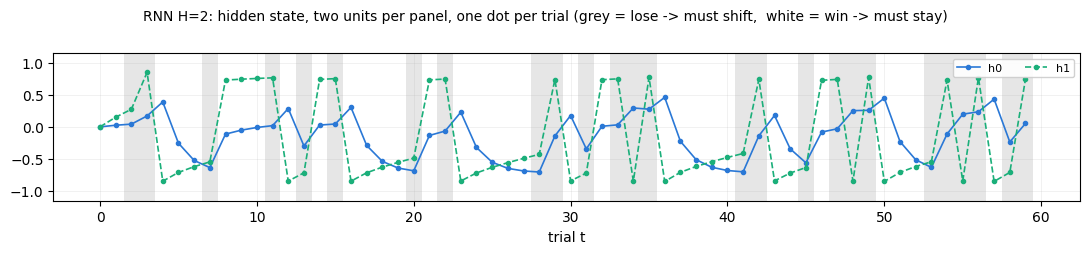

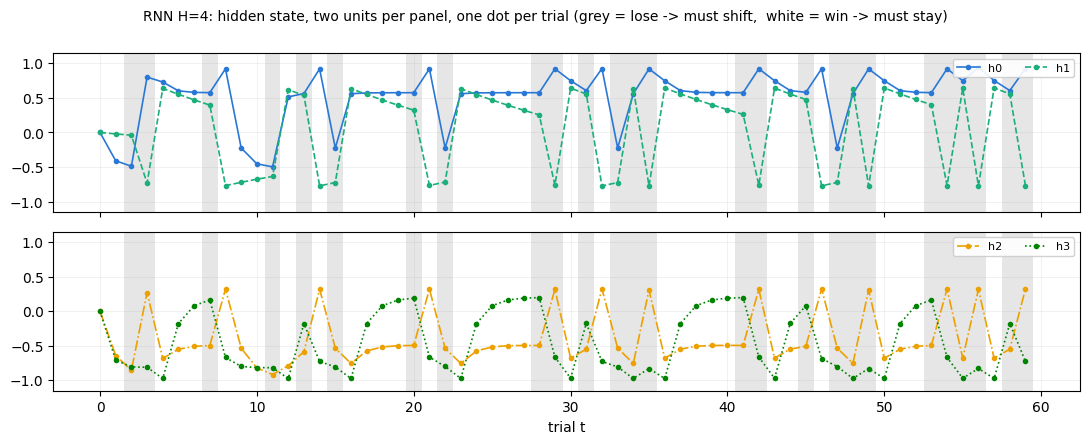

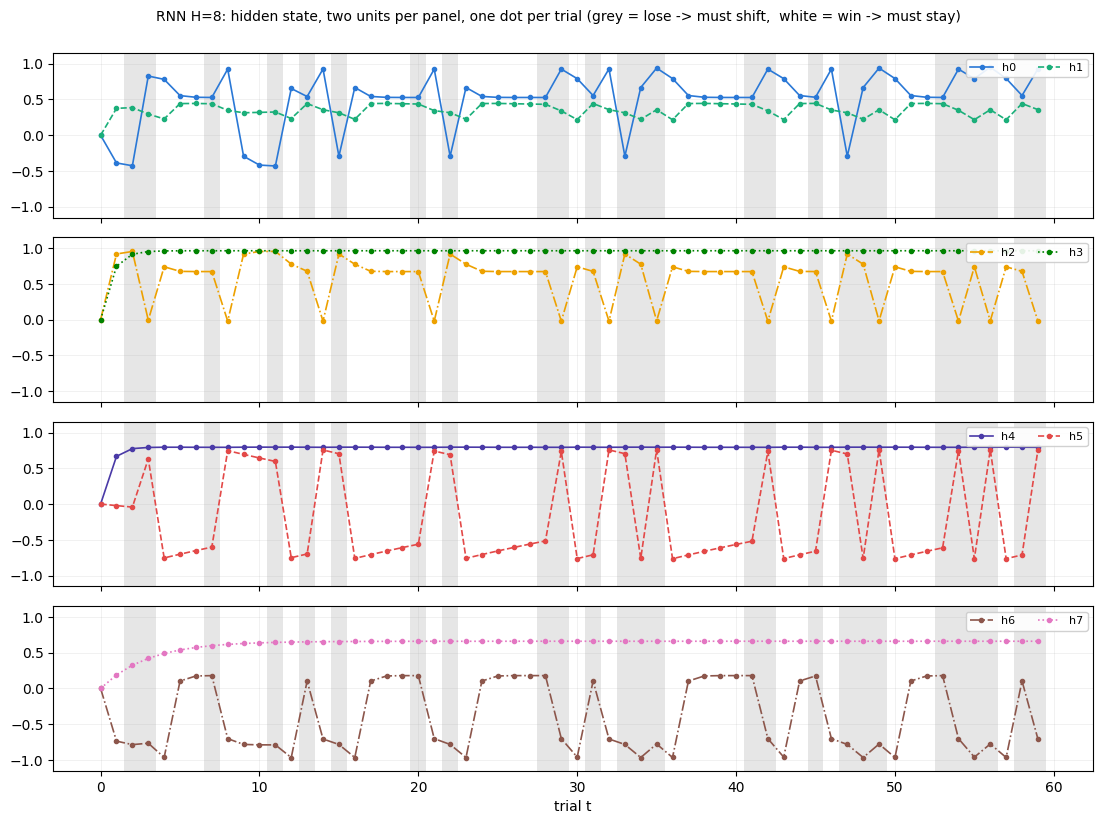

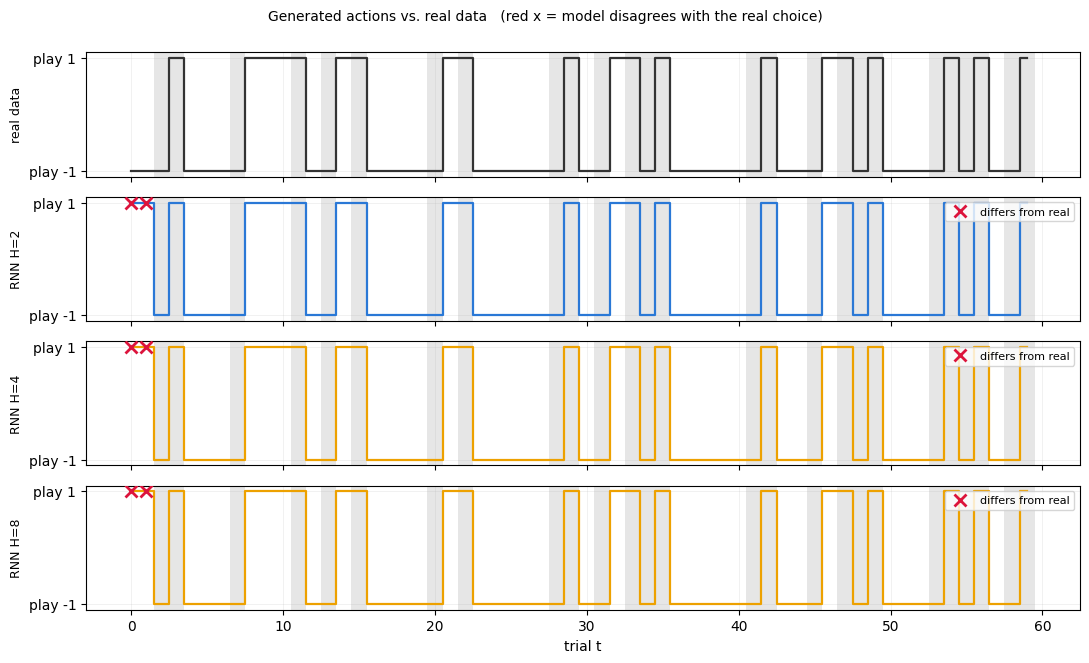

Each hidden trace is flat inside a white run (staying) and flips at grey columns
(shifting) -- the hidden state is holding 'which arm am I on', nothing more.
H=2: 2/60 trials mismatch.  first mismatch at trial 0
   from first mismatch onward: 3.3% mismatch rate
   trial 0: real action = 0, generated action = 1, generated P(action) from h0 = [0.588 0.412]
H=4: 2/60 trials mismatch.  first mismatch at trial 0
   from first mismatch onward: 3.3% mismatch rate
   trial 0: real action = 0, generated action = 1, generated P(action) from h0 = [0.449 0.551]
H=8: 2/60 trials mismatch.  first mismatch at trial 0
   from first mismatch onward: 3.3% mismatch rate
   trial 0: real action = 0, generated action = 1, generated P(action) from h0 = [0.488 0.512]


In [33]:
# --- 6.3 -- Hidden state and generated actions over time ----------------------------
# Colors: the dataviz reference palette, assigned to units in fixed slot order (never
# cycled); linestyle varies too, so a unit's identity never rests on hue alone.
PALETTE    = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#8c564b", "#e377c2"]
LINESTYLES = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
N_SHOW  = 60                      # first 60 trials -- enough to see the rule, few enough to read
example = test_sessions[0]
gen = {H: generate_rnn_trajectory(rnn_params[H], example["observations"], np.random.default_rng(0))
       for H in H_TO_COMPARE}

def shade_losses(ax, session, n=N_SHOW):
    """Grey column = a LOSE trial (the rule says shift); white = a WIN (stay).
    With this shading the whole WSLS rule is readable straight off the plot."""
    for i in range(n):
        if session["observations"][i] == 0:
            ax.axvspan(i - 0.5, i + 0.5, color="0.90", lw=0, zorder=0)

t = np.arange(N_SHOW)

def _unit_pairs(H):
    """Group hidden units two-at-a-time: [(0,1),(2,3),...]. Second index may be >= H for odd H."""
    return [(2 * k, 2 * k + 1) for k in range((H + 1) // 2)]

# One hidden vector per TRIAL -- discrete points, not a continuous signal. The connecting line
# just traces the ordered trial-to-trial sequence; the marker dots are the actual data. TWO units
# per subplot: not all H overlaid in one axes (unreadable at H=8), and not one axes per unit
# (wastes space) -- ceil(H/2) panels, at most two clearly-distinguished traces each.
for H in H_TO_COMPARE:
    pairs = _unit_pairs(H)
    fig, axes = plt.subplots(len(pairs), 1, sharex=True, figsize=(11, 1.9 * len(pairs) + 0.6))
    axes = np.atleast_1d(axes)
    for ax, (u0, u1) in zip(axes, pairs):
        shade_losses(ax, example)
        for u in (u0, u1):
            if u >= H:
                continue
            ax.plot(t, gen[H]["hidden"][:N_SHOW, u], color=PALETTE[u], ls=LINESTYLES[u],
                    marker="o", ms=3, lw=1.2, label=f"h{u}")
        ax.set_ylim(-1.15, 1.15); ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
        ax.legend(loc="upper right", ncol=2, fontsize=8, framealpha=0.9)
    axes[-1].set_xlabel("trial t")
    fig.suptitle(f"RNN H={H}: hidden state, two units per panel, one dot per trial "
                 "(grey = lose -> must shift,  white = win -> must stay)", y=0.999, fontsize=10)
    plt.tight_layout(); plt.show()

# Generated actions -- both sizes vs. the real data. Actions are binary and the models agree
# with the real choice ~99.9% of the time, so three overlaid step-lines mostly sit exactly on
# top of each other: agreement is invisible, and the rare disagreement -- the one thing worth
# seeing -- can get hidden under whichever line draws last. One row per series instead, plus an
# explicit marker at every trial where that model's action differs from the real one.
real_acts = example["actions"][:N_SHOW]
rows = [("real data", real_acts, "0.2")] + [
    (f"RNN H={H}", gen[H]["actions"][:N_SHOW], PALETTE[0] if H == H_TO_COMPARE[0] else PALETTE[2])
    for H in H_TO_COMPARE
]
fig, axes = plt.subplots(len(rows), 1, sharex=True, figsize=(11, 1.5 * len(rows) + 0.6))
for ax, (label, acts, color) in zip(axes, rows):
    shade_losses(ax, example)
    ax.step(t, acts, where="mid", color=color, lw=1.6)
    mismatch = acts != real_acts
    if mismatch.any():
        ax.plot(t[mismatch], acts[mismatch], "x", color="crimson", ms=8, mew=2, zorder=5,
                 label="differs from real")
        ax.legend(loc="upper right", fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"play {ActSpace[0]}", f"play {ActSpace[1]}"])
    ax.set_ylabel(label, fontsize=9)
    ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
axes[-1].set_xlabel("trial t")
fig.suptitle("Generated actions vs. real data   (red x = model disagrees with the real choice)",
             y=0.998, fontsize=10)
plt.tight_layout(); plt.show()

print("Each hidden trace is flat inside a white run (staying) and flips at grey columns")
print("(shifting) -- the hidden state is holding 'which arm am I on', nothing more.")
# Why a whole generated trajectory can be the MIRROR of the real one (every trial "differs")
# yet still score ~100% on WSLS: the RNN starts from a fixed blank state h0=0, so its FIRST
# action is a near-coin-flip that cannot know which arm THIS session actually opened on. If it
# guesses the other arm, then from trial 1 on both trajectories obey the identical outcome-driven
# rule (stay on win, shift on loss) and stay exactly one step out of phase -- WSLS has no
# restoring force to pull them back in sync. So the mismatch is a single trial-0 coin flip, not a
# bug; §6.5 / §6.6 pursue this first-action question properly.
for H in H_TO_COMPARE:
    acts = gen[H]["actions"][:N_SHOW]
    mism = np.where(acts != real_acts)[0]
    print(f"H={H}: {len(mism)}/{N_SHOW} trials mismatch."
          f"  first mismatch at trial {mism[0] if len(mism) else None}")
    if len(mism):
        print(f"   from first mismatch onward: "
              f"{(acts[mism[0]:] != real_acts[mism[0]:]).mean()*100:.1f}% mismatch rate")
    print(f"   trial 0: real action = {real_acts[0]}, generated action = {gen[H]['actions'][0]},"
          f" generated P(action) from h0 = {np.round(gen[H]['probs'][0], 3)}")


### 6.4 The head-to-head: the action-transition matrix

Now the object from the whiteboard:

$$P(A_t = a' \mid A_{t-1} = a,\ Y_{t-1} = y)$$

**How each model's matrix is built.** Identically, so the comparison is fair: replay the same
held-out sessions through the model, take the probability it assigns to each action at trial
`t`, and average those probabilities over all trials sharing the same `(a_{t-1}, y_{t-1})`.
It's a **marginal** — each model's full internal state is integrated out, leaving only what the
last (action, outcome) pair predicts.

That marginalization is the point, and it cuts differently for the two models:

- For the **FSC** the matrix is essentially exact by construction — its memory transition
  *is* a function of `(action, observation)`, so conditioning on that pair is conditioning on
  what the model actually uses.
- For the **RNN** it's a genuine summary, not an identity. The hidden state could in principle
  depend on the whole history, so the matrix is only the *average* behavior across histories.
  It comes out clean exactly to the extent the RNN really has collapsed to a 1-step rule.

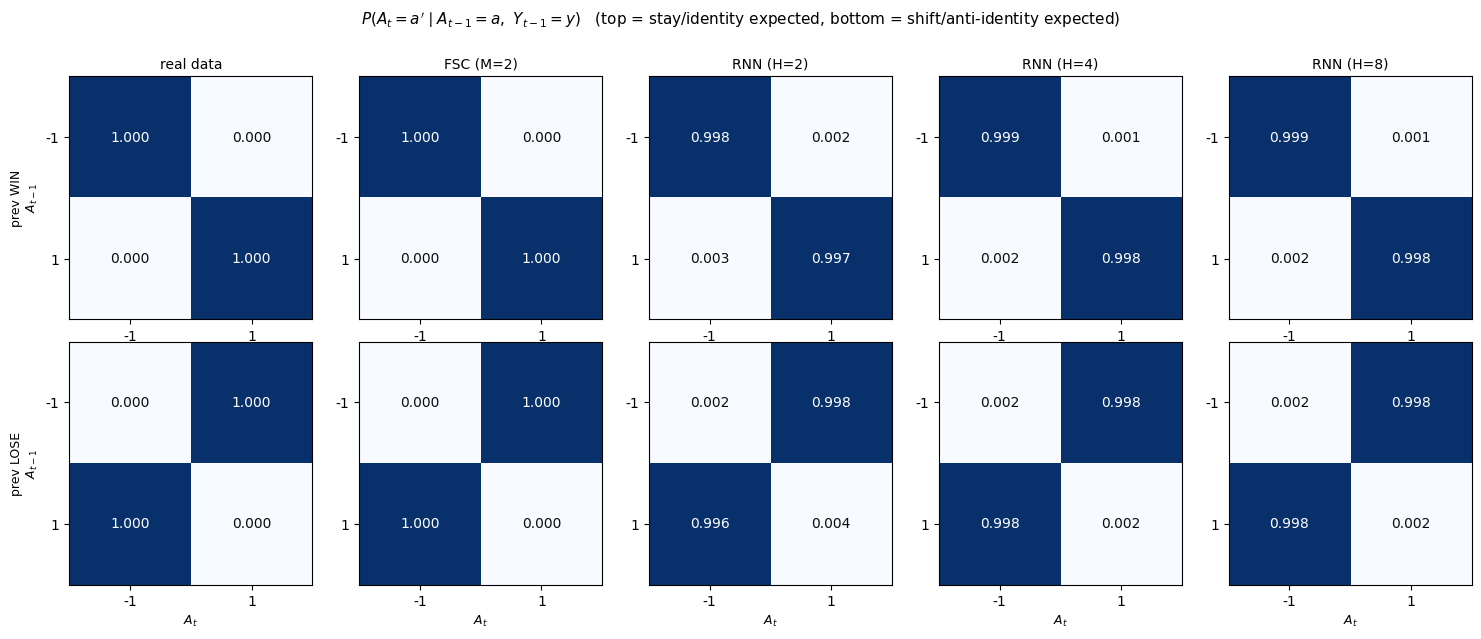

Largest absolute deviation from the real data's matrix:
   FSC (M=2)      0.00000
   RNN (H=2)      0.00383
   RNN (H=4)      0.00230
   RNN (H=8)      0.00216


In [34]:
# --- 6.4 -- P(A_t | A_{t-1}, Y_{t-1}) for the data, the FSC, and each RNN ------------
def empirical_action_matrix(session_list):
    """Straight counting on the real behavior -- the ground truth to compare against."""
    acc = np.zeros((Y, A, A)); cnt = np.zeros((Y, A))
    for s in session_list:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            acc[int(o[t-1]), int(a[t-1]), int(a[t])] += 1
            cnt[int(o[t-1]), int(a[t-1])] += 1
    return acc / cnt[..., None]

def rnn_action_matrix(P, session_list):
    """Replay each session (teacher-forced, so the RNN sees exactly the histories the FSC
    sees) and average its predicted P(a_t | history) within each (prev action, prev obs) cell."""
    acc = np.zeros((Y, A, A)); cnt = np.zeros((Y, A))
    for s in session_list:
        a, o = s["actions"], s["observations"]
        h = np.zeros(P["H"])
        for t in range(len(a)):
            p = rnn_action_probs(h, P)
            if t >= 1:
                acc[int(o[t-1]), int(a[t-1])] += p
                cnt[int(o[t-1]), int(a[t-1])] += 1
            h, _ = gru_step(h, rnn_encode_input(int(a[t]), int(o[t])), P)
    return acc / cnt[..., None]

def fsc_action_matrix(fsc, session_list):
    """Same recipe, using the FSC's own belief recursion (as in §8 / §4.1)."""
    fsc.set_mode("generation")
    T_mat = fsc.get_TMat(); rho = np.asarray(fsc.get_rho()); pol = np.asarray(fsc.get_action_policy())
    acc = np.zeros((Y, A, A)); cnt = np.zeros((Y, A))
    for s in session_list:
        a, o = s["actions"], s["observations"]
        b = rho.copy()
        for t in range(len(a)):
            p = b @ pol
            if t >= 1:
                acc[int(o[t-1]), int(a[t-1])] += p
                cnt[int(o[t-1]), int(a[t-1])] += 1
            bn = b @ T_mat[int(o[t]), :, :, int(a[t])]; tot = bn.sum()
            b = bn / tot if tot > 0 else np.ones(fsc.M) / fsc.M
    return acc / cnt[..., None]

_use_fsc_path(); best_fsc.set_mode("generation")
action_mats = {"real data": empirical_action_matrix(test_sessions),
               f"FSC (M={M_STAR})": fsc_action_matrix(best_fsc, test_sessions)}
for H in H_TO_COMPARE:
    action_mats[f"RNN (H={H})"] = rnn_action_matrix(rnn_params[H], test_sessions)

# Sequential single-hue ramp (magnitude 0..1), values direct-labelled in every cell.
fig, axes = plt.subplots(Y, len(action_mats), figsize=(3.0 * len(action_mats), 3.1 * Y))
for j, (name, Mx) in enumerate(action_mats.items()):
    for i, y in enumerate([1, 0]):                       # win row on top, lose row below
        ax = axes[i, j]
        ax.imshow(Mx[y], cmap="Blues", vmin=0, vmax=1)
        for r in range(A):
            for c in range(A):
                v = Mx[y][r, c]
                ax.text(c, r, f"{v:.3f}", ha="center", va="center", fontsize=10,
                        color="white" if v > 0.5 else "#0b0b0b")
        ax.set_xticks(range(A)); ax.set_xticklabels([str(v) for v in ActSpace])
        ax.set_yticks(range(A)); ax.set_yticklabels([str(v) for v in ActSpace])
        if i == 0: ax.set_title(name, fontsize=10)
        if j == 0: ax.set_ylabel(f"prev {'WIN' if y == 1 else 'LOSE'}\n$A_{{t-1}}$", fontsize=9)
        if i == Y - 1: ax.set_xlabel("$A_t$", fontsize=9)
fig.suptitle("$P(A_t = a' \\mid A_{t-1} = a,\\ Y_{t-1} = y)$   "
             "(top = stay/identity expected, bottom = shift/anti-identity expected)",
             y=1.01, fontsize=11)
plt.tight_layout(); plt.show()

truth = action_mats["real data"]
print("Largest absolute deviation from the real data's matrix:")
for name, Mx in action_mats.items():
    if name == "real data":
        continue
    print(f"   {name:<14s} {np.abs(Mx - truth).max():.5f}")

### 6.5 The first action — the one place the two sizes disagree

The first trial is the only one where a model has **no information**: no previous action, no
previous outcome. For the RNN that makes `P(A_0)` an exact, closed-form quantity — `h0` is
pinned to all-zeros (`trainable_h0=False`), so

$$P(A_0) = \text{softmax}(\text{Linear}(\mathbf{0})) = \text{softmax}(\text{readout bias})$$

no sampling required. This is the one place H=2 and H=4 part company.

> **Scope note.** The full first-action analysis — the FSC's own initial distribution `rho`, and
> the fixed-init vs random-init contrast — is a separate piece of work and is deliberately *not*
> done here. We take only the two numbers the H=2-vs-H=4 question needs.

In [35]:
# --- 6.5 -- P(first action): H=2 vs H=4 ---------------------------------------------
# h0 is all-zeros, so each run's answer is just softmax(readout bias) -- exact, not sampled.
# Every run at each size is shown. These are outer folds of ONE cross-validation, so they
# share training data and are NOT independent replicates: read the spread as consistency,
# not as an error bar.
real_first = (np.bincount([int(s["actions"][0]) for s in encoded_sessions], minlength=A)
              / len(encoded_sessions))
print(f"The data's own first-action split (actions {ActSpace}): {np.round(real_first, 4)}\n")
print(f"P(first action = {ActSpace[0]}) predicted by each run:")
for H in H_TO_COMPARE:
    vals = np.array([rnn_action_probs(np.zeros(H), P)[0] for P in rnn_params_folds[H]])
    print(f"   H={H}:  {np.round(vals, 3)}    mean {vals.mean():.3f}")
print("\nH=2 is skewed where H=4 is not, consistently across every run -- and this is the")
print("only robust difference between the two sizes anywhere in this notebook.")

The data's own first-action split (actions [-1  1]): [0.488 0.512]

P(first action = -1) predicted by each run:
   H=2:  [0.588 0.59  0.607 0.576 0.612]    mean 0.594
   H=4:  [0.449 0.424 0.506 0.414 0.423]    mean 0.443
   H=8:  [0.488 0.49  0.511 0.524 0.493]    mean 0.501

H=2 is skewed where H=4 is not, consistently across every run -- and this is the
only robust difference between the two sizes anywhere in this notebook.


### 6.6 — [OPEN] Does the first action match how the data was initialised?

§6.5 deliberately answers only the narrow H=2-vs-H=4 question. The full first-action check is
**open, and belongs here**. Two pieces:

1. **The FSC's own first action.** It has an explicit parameter for this, unlike the RNN:
   `P(A_0) = rho @ policy`. One line, after `_use_fsc_path(); best_fsc.set_mode("generation")` —
   `np.asarray(best_fsc.get_rho()) @ np.asarray(best_fsc.get_action_policy())`. Compare it to
   `real_first` (computed in §6.5) and to the RNN.
2. **The initialisation contrast.** `random_init` should come out ~50/50; `det_init` should
   instead *reproduce* its fixed starting action.

> **Two gotchas before you start.**
>
> **This notebook runs one dataset per pass.** `DATASET` in §1.1a routes both the data *and* the
> per-dataset model folders, so the contrast is **two runs, not one cell** — run it through, record
> the numbers, flip `DATASET`, run again. (If you want them side by side in a single cell instead,
> you'd have to load both datasets' fitted models directly from `fitted_models/` and
> `tinyRNN/files/saved_model/exp_<dataset>/`, bypassing §1.)
>
> **`det_init` has no fitted models yet** — `fitted_models/` and `tinyRNN/files/saved_model/` only
> contain `random_init` (and the older `original`). So §2 and §3 have to run with
> `DATASET = "det_init"` first, and that's the slow part. See §3.2's note about running one process
> per `hidden_dim` in parallel if the sweep is too slow single-process.

**Already available — reuse rather than rewrite:**

| what | where |
|---|---|
| `rnn_action_probs(np.zeros(H), rnn_params[H])` | exact `P(A_0)` for the RNN — `h0` is all-zeros, so this is closed-form, **no sampling needed** |
| `rnn_params_folds[H]` | every run at size `H`, if you want the spread across folds |
| `real_first` | the data's own first-action split (§6.5) |
| `generate_rnn_trajectory(P, obs, rng)` | §6.2 — if you'd rather measure it by sampling than read it off the readout bias |

Note that §6.2 and §6.3 already cover the *generate-and-check* analysis (`p(stay|win)`,
`p(change|lose)`, hidden states and actions over time), for H=2 **and** H=4 — they had to exist for
the size sub-study. Reuse them; there should be no need to write a second generation loop.

In [36]:
# --- 6.6a -- The FSC's own first-action prediction, vs. the data and the RNNs (§6.5) ---
_use_fsc_path()
best_fsc.set_mode("generation")
fsc_first_action = np.asarray(best_fsc.get_rho()) @ np.asarray(best_fsc.get_action_policy())

print(f"Dataset = {DATASET!r}")
print(f"P(first action = {ActSpace[0]}):")
print(f"   real data:    {real_first[0]:.4f}")
print(f"   FSC (M*={M_STAR}):  {fsc_first_action[0]:.4f}")
for H in H_TO_COMPARE:
    vals = np.array([rnn_action_probs(np.zeros(H), P)[0] for P in rnn_params_folds[H]])
    print(f"   RNN H={H}:      mean {vals.mean():.4f}  (range {vals.min():.4f}-{vals.max():.4f})")


Dataset = 'random_init'
P(first action = -1):
   real data:    0.4880
   FSC (M*=2):  0.4881
   RNN H=2:      mean 0.5943  (range 0.5757-0.6115)
   RNN H=4:      mean 0.4433  (range 0.4138-0.5064)
   RNN H=8:      mean 0.5012  (range 0.4882-0.5235)


In [37]:
# --- 6.6b -- The initialisation contrast: det_init vs random_init, side by side --------
# Bypasses DATASET (per the note above): loads both datasets' ALREADY-FITTED models
# directly from fitted_models/ and tinyRNN's saved_model archive. Read-only -- does not
# retrain anything, does not change DATASET, and does not touch the notebook's existing
# per-dataset globals (best_fsc, rnn_params, H_STAR, ... all stay exactly as §1-§6 left them).
import glob

assert set(np.load("datasets/wsls_actions_observations_random_init.npz")["actions"].ravel().tolist()) \
       == set(np.load("datasets/wsls_actions_observations_det_init.npz")["actions"].ravel().tolist()), \
       "the two datasets encode actions differently -- the comparison below would be invalid"

def _load_fsc_first_action(dataset):
    _use_fsc_path()
    path = glob.glob(f"fitted_models/{dataset}/fsc/best_fsc_M*.pkl")[0]
    with open(path, "rb") as f:
        fsc = pickle.load(f)
    fsc.set_mode("generation")
    return float((np.asarray(fsc.get_rho()) @ np.asarray(fsc.get_action_policy()))[0])

def _load_rnn_first_action(dataset):
    """Restores the archived RNN fits into tinyRNN's live cache if missing (same
    non-destructive copy §3.2 already does), reads off the dataset's own selected H*,
    and computes P(first action) the same closed-form way §6.5 does (h0 = zeros)."""
    _use_tinyrnn_path()
    exp_folder = f"exp_{dataset}"
    live_dir = f"tinyRNN/files/saved_model/{exp_folder}"
    archive_dir = f"fitted_models/{dataset}/rnn/{exp_folder}"
    if not os.path.isdir(live_dir) and os.path.isdir(archive_dir):
        shutil.copytree(archive_dir, live_dir)
        print(f"   (restored {archive_dir} -> {live_dir})")

    os.chdir("tinyRNN")
    try:
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary_ds, dim_est_ds = select_final_rnn_perf(exp_folder, return_dim_est=True, verbose=False)
        improved = dim_est_ds.loc[dim_est_ds["less_than_former"] == 1, "hidden_dim"]
        h_star_ds = int(improved.max()) if len(improved) else int(dim_est_ds["hidden_dim"].min())
        rows = summary_ds[summary_ds["hidden_dim"] == h_star_ds].sort_values("trainval_loss")
        cfg = dict(base_config); cfg.update({"hidden_dim": h_star_ds, "seed": 0, "exp_folder": exp_folder})
        ag = Agent("RNN", config=cfg)
        ag.load(str(rows.iloc[0]["model_path"]))
        P = extract_gru_params(ag)
    finally:
        os.chdir("..")
    return h_star_ds, float(rnn_action_probs(np.zeros(P["H"]), P)[0])

init_contrast = {}
for dataset in ["random_init", "det_init"]:
    raw = np.load(f"datasets/wsls_actions_observations_{dataset}.npz")
    real_first_ds = float((raw["actions"][:, 0] == ActSpace[0]).mean())
    fsc_first_ds = _load_fsc_first_action(dataset)
    h_star_ds, rnn_first_ds = _load_rnn_first_action(dataset)
    init_contrast[dataset] = dict(real=real_first_ds, fsc=fsc_first_ds, H=h_star_ds, rnn=rnn_first_ds)

_use_fsc_path()  # restore FSC path for anything downstream in the notebook

print(f"P(first action = {ActSpace[0]}) -- initialisation contrast (real data / FSC / RNN):\n")
for dataset, r in init_contrast.items():
    print(f"   {dataset:<13} real={r['real']:.4f}   FSC={r['fsc']:.4f}   RNN (H={r['H']})={r['rnn']:.4f}")


Searching for summary files...
Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 1028.80it/s]

Searching for summary files...


Found 8 summary files.
Filtering by {'agent_type': 'RNN'}


100%|██████████| 8/8 [00:00<00:00, 1107.26it/s]

P(first action = -1) -- initialisation contrast (real data / FSC / RNN):

   random_init   real=0.4880   FSC=0.4881   RNN (H=5)=0.4813
   det_init      real=1.0000   FSC=1.0000   RNN (H=8)=0.9739


## 7. Do the two models actually share an internal representation?

By now we have, for **every trial**, two separate readouts of "what the model is thinking":
the FSC's belief and the RNN's hidden state. Sections 5.1-5.2 showed both line up with the
recent (action, outcome) history -- but that was by eye. Now we test it directly with a
**linear probe**: train a simple classifier to predict *one* model's state from the *other*
model's state, and see how accurate it gets. If a plain straight-line classifier can do it, the
information is genuinely *inside* that representation, not just visually suggestive.

**The exact variables the probe uses** (each has one row per trial, all aligned to the same
trials). `mask` drops the first slot of each session -- the state *before trial 1* -- for two
reasons: it has no preceding (action, outcome) to label it with, and it's the same generic
"haven't started yet" state for every session, so it carries no information. That drops each
session by one trial, leaving **N** usable trials in total.

| variable | what it is | shape |
|---|---|---|
| `decide_time_rnn` | the RNN's hidden numbers at each trial -- one per hidden unit (from 5.2) | (N, H) |
| `decide_time_fsc` | the FSC's belief -- one probability per FSC state, i.e. how likely each state is (from 5.1) | (N, M) |
| `hard_states` | which FSC state is the winner that trial (0 … M-1) | (N,) |
| `km.labels_` | which of the RNN's clusters that trial fell into (0 … K-1, from 5.2) | (N,) |

> **For the dataset loaded here:** M = 2 FSC states, H = 5 RNN hidden units, K = 4 RNN clusters,
> and N = 1000 sessions × 199 trials = **199,000** trials. (These four numbers are what change
> when you swap the dataset; everything below is written in terms of M, H, K, N so it stays correct.)

We run the probe in **both directions** -- in each, one array is the *input features* and the
other model's label is the *target to predict*:

- **A) RNN → FSC:** features = `decide_time_rnn` (the RNN's hidden numbers), target = `hard_states`
  (the FSC's state). A high score means the RNN already encodes whatever the FSC's state captures.
- **B) FSC → RNN:** features = `decide_time_fsc` (the FSC's belief), target = `km.labels_`
  (the RNN's cluster). If this is much weaker than A, the RNN is holding information the FSC discards.

**How the accuracy is scored -- and note this is _not_ the Section 2 fit/validation/test split.**
That split existed only to choose the FSC's number of states. The probe is a different question,
so it scores itself with its own **5-fold cross-validation**: chop the trials into 5 equal parts,
train the classifier on 4 parts, score it on the 5th part it never saw, rotate so each part is the
held-out one exactly once, and average the 5 scores. Cross-validation just guarantees the
classifier is always graded on trials it didn't train on, so the number isn't inflated by
memorization.


### How the linear probe works

For each trial you have an input vector **X** (one model's internal state) and a target label **y**
(the *other* model's state). A logistic-regression classifier turns X into a guess in two steps:

1. **Weighted sum -- the "linear" part.** With learned weights **w** (one per input number) and a
   learned bias **b**:  `z = w·X + b = w₁X₁ + w₂X₂ + … + b`.
2. **Squash to a probability.** When the target has **2 classes** (e.g. predicting the FSC's state
   when M=2), the logistic (sigmoid) function: `P(class = 1) = σ(z) = 1 / (1 + e^(−z))`, and predict
   class 1 if that is above 0.5. When it has **more than 2** classes (e.g. the K RNN clusters) it's
   the *softmax* version: one score `z_k = w_k·X + b_k` per class, then
   `P(class k) = e^(z_k) / Σ_j e^(z_j)`, predict the highest.

**What is actually trainable: only `w` and `b`.** X and y are fixed data -- X is the internal-state
vector you feed *in*, y is the answer you're trying to hit. The weights set the *orientation* of the
decision boundary; the bias sets *where it sits* (like the `+b` intercept in `y = mx + b` -- without
it the boundary is forced through the all-zeros input point). There is one weight per input feature
(**H** for the RNN's hidden vector, **M** for the FSC's belief) and one bias per output.

**Training = choosing `w`, `b`** to make the predicted probabilities match the true labels, by
minimizing the cross-entropy loss `L = −Σ ln P(correct label)` with gradient descent. (In the code,
`StandardScaler` first rescales each feature to mean 0 / spread 1 so the optimizer converges nicely;
it doesn't change what's being asked.)

**Why deliberately use the weakest classifier.** A linear probe can only draw straight boundaries.
If even a straight boundary reads one representation out of the other perfectly, the information
isn't just present -- it's present *cleanly* (linearly separable). A near-100% score with a linear
probe is the strongest possible version of "these two internal states encode the same thing."


In [38]:
# --- 7.1 -- Linear probes between the two models' internal states --------------------
# A "probe" = train a simple linear classifier to predict one model's internal state from the
# other's, and measure how well it does on held-out trials. High accuracy => the information is
# actually present in that representation (linearly readable), not just visually similar.
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# --- the ingredients (each row = one trial; the two arrays are aligned to the SAME trials) ---
# `mask` drops each session's very first trial, which has no preceding trial to define a state.
Xr = decide_time_rnn[mask]   # candidate FEATURES A: the RNN's hidden vector per trial   (N x 4)
Xf = decide_time_fsc[mask]   # candidate FEATURES B: the FSC's belief per trial           (N x 2)
yf = hard_states[mask]       # LABEL: which FSC memory state (0/1) the FSC is in that trial
yr = km.labels_              # LABEL: which of the RNN's 4 clusters (0..3) that trial falls in
print(f"Trials used: {mask.sum():,}   (RNN state = {Xr.shape[1]} numbers, FSC belief = {Xf.shape[1]} numbers)")
print(f"Targets: FSC has {len(np.unique(yf))} states to predict, RNN has {len(np.unique(yr))} clusters.\n")

def probe(X, y):
    """Train a linear classifier to predict y from X; return its 5-fold cross-validated accuracy."""
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # silence the benign Apple-BLAS matmul noise (values are correct)
        return cross_val_score(clf, X, y, cv=5).mean()

# Experiment A -- features = RNN hidden state, target = FSC state:
accA = probe(Xr, yf); chanceA = np.bincount(yf).max() / len(yf)   # chance = always guess commonest class
# Experiment B -- features = FSC belief, target = RNN cluster:
accB = probe(Xf, yr); chanceB = np.bincount(yr).max() / len(yr)

print(f"A)  RNN hidden  ->  FSC state   :  {accA*100:5.1f}%    (chance = {chanceA*100:.1f}%)")
print(f"B)  FSC belief  ->  RNN cluster :  {accB*100:5.1f}%    (chance = {chanceB*100:.1f}%)")

Trials used: 199,000   (RNN state = 6 numbers, FSC belief = 2 numbers)
Targets: FSC has 2 states to predict, RNN has 4 clusters.

A)  RNN hidden  ->  FSC state   :  100.0%    (chance = 51.2%)
B)  FSC belief  ->  RNN cluster :   57.9%    (chance = 30.1%)


### Reading the two numbers

**Accuracy** is the share of held-out trials where the classifier guessed the target right.
**Chance** is the score you'd get *without* looking at the features at all -- by always guessing
the single most common answer. What matters is the **gap** between them: accuracy near chance
means "the features tell you nothing"; accuracy far above chance means "the features carry the
answer." (Chance differs between the two directions only because the number of possible answers
differs -- M FSC states vs K RNN clusters -- so more classes means a lower blind-guess baseline.)

Read each direction against its own chance line, then compare the two directions to each other.
If one direction sits far above chance while the other is stuck near it, the two representations
are **not** interchangeable: one holds information the other doesn't.

> **For this WSLS dataset (exact numbers are printed above):**
> - **A) RNN → FSC ≈ 100%, vs ~50% chance.** The FSC has M=2 states split ~50/50, so blind
>   guessing scores ~50%. The classifier instead hits ~100% -- the RNN's hidden numbers
>   *completely determine* the FSC's state. The RNN already contains everything the FSC's state encodes.
> - **B) FSC → RNN ≈ the win rate, well below A.** The RNN has K=4 clusters, so blind guessing
>   scores only ~1/K. The FSC's state isn't "nothing" -- it tells you which **pair** of clusters
>   you're in, so you're choosing among 2, not 4. But it can't split *within* the pair, so it tops
>   out at the fraction of trials it can actually pin down. For WSLS that ceiling equals the data's
>   **win rate**: inside each FSC state the two merged clusters are one win-context and one
>   loss-context; wins are the more common, so the best remaining bet is always "it was a win" --
>   exactly the win rate. The part it *can't* recover is precisely the win/lose bit the FSC throws
>   away. (In our run this ceiling also lands near 2× the chance line, because the two winning
>   clusters happen to be nearly equal in size -- a coincidence of this data, not a rule.)

### What this tells us

The asymmetry is the whole story. When one model's state predicts the other's almost perfectly
while the reverse hits a hard ceiling, one internal state is a **strict superset** of the other:
it contains everything the smaller one has, plus extra detail the smaller one never keeps.

> **For this WSLS dataset:** it's the RNN that is the superset. On its own it rediscovered exactly
> the distinction the FSC makes explicit (direction A ≈ 100%), while the FSC's belief recovers the
> RNN's cluster only up to the right *pair* (direction B, capped at the win rate), because the FSC
> deliberately merges each win-context with the loss-context that implies the same next move. The
> gap between B and 100% is the size of exactly that one thrown-away bit. Both models predict
> behavior equally well (Section 8), so here that extra RNN detail buys nothing -- the FSC's 2
> states are enough, more interpretable, and far cheaper.

But WSLS is a deterministic, one-bit rule -- the right task to *validate the method* on (we know
the answer, and the probe recovers it cleanly), and the wrong task to decide "is the RNN's extra
capacity ever worth it?" in general. The real test is to point this same machinery at a harder
dataset -- one with noise or longer memory -- where the RNN's extra capacity might finally earn
its keep. That's the natural next experiment.


## 8. Which model predicts behavior better?

§7 asked whether the two models *represent* the same thing. This asks the plainer question: on
held-out trials, which one assigns higher probability to the action that actually happened?

This is the fair version of a comparison that is easy to get wrong. Averaged losses from the two
libraries are **not** comparable — they're computed on different data by different equations. So
we use each model's **predicted probability of the action that actually occurred**, per trial, on
the **same held-out test sessions** (both models held these out while fitting).

Comparing on 200 held-out test sessions (40,000 trials).

METHOD 1 -- predictive per-trial log-likelihood (higher = better; nats):
   FSC:  mean log-lik = -0.00347   (NLL 0.00347)
   RNN:  mean log-lik = -0.00529   (NLL 0.00529)
   paired: FSC assigns higher P to the truth on 99.73% of trials, RNN on 0.27%
   [synthetic-from-FSC sanity check, FSC should be >= RNN]: PASS

METHOD 2 -- do the two models assign the same probability per trial?
   correlation of per-trial P(actual action): r = 0.9810
   mean |P_FSC - P_RNN| per trial = 0.00190


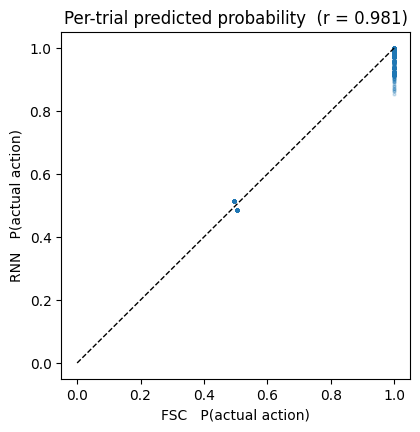

In [39]:
# --- 8 -- Compare the two models fairly: predicted probability, same held-out trials ----
# The OLD comparison plotted two averaged LOSSES computed on different data by different
# equations -- not valid. The fair comparison uses each model's PREDICTED PROBABILITY of the
# action that actually happened, per trial, on the SAME held-out test sessions (both models
# held these out while fitting). From those per-trial probabilities we run two methods:
#   Method 1 -- predictive log-likelihood, paired per trial: which model predicts behavior better.
#   Method 2 -- per-trial probability agreement: do the two models "think" alike, trial by trial.
_use_fsc_path()   # restore FSC modules (Section 3 left tinyRNN on sys.path)

def fsc_per_trial_prob(fsc, session_list):
    """Per-trial P(actual action | history) under the FSC, from its own belief recursion.
    General -- works for any number of actions / memory states."""
    fsc.set_mode("generation")
    T_mat = fsc.get_TMat(); rho = np.asarray(fsc.get_rho()); pol = np.asarray(fsc.get_action_policy())
    out = []
    for s in session_list:
        a, o = s["actions"], s["observations"]
        b = rho.copy(); p = np.zeros(len(a))
        for t in range(len(a)):
            p[t] = (b @ pol)[int(a[t])]                       # P(chosen action | current belief)
            step = T_mat[int(o[t]), :, :, int(a[t])]          # advance the belief with what happened
            bn = b @ step; tot = bn.sum()
            b = bn / tot if tot > 0 else np.ones(fsc.M) / fsc.M
        out.append(p)
    return out

# FSC used here = the sweep model at M* (fit on the FIT set -> holds out test), NOT the all-data
# best_fsc from 2.3. rnn_test_probs came from 3.4 and were also held out from test.
fsc_test_probs = fsc_per_trial_prob(fitted_fscs[M_STAR], test_sessions)

fp = np.concatenate(fsc_test_probs)
rp = np.concatenate([rnn_test_probs[i][:len(fsc_test_probs[i])] for i in range(len(fsc_test_probs))])
fll = np.log(np.clip(fp, 1e-300, 1.0)); rll = np.log(np.clip(rp, 1e-300, 1.0))

print(f"Comparing on {len(test_sessions)} held-out test sessions ({len(fp):,} trials).\n")
print("METHOD 1 -- predictive per-trial log-likelihood (higher = better; nats):")
print(f"   FSC:  mean log-lik = {fll.mean():.5f}   (NLL {-fll.mean():.5f})")
print(f"   RNN:  mean log-lik = {rll.mean():.5f}   (NLL {-rll.mean():.5f})")
print(f"   paired: FSC assigns higher P to the truth on {100*np.mean(fll > rll):.2f}% of trials, "
      f"RNN on {100*np.mean(rll > fll):.2f}%")
# For data generated by an FSC, the FSC is the ground truth -> it should not be beaten. This
# line is a dataset-specific sanity check, not part of the general method.
print(f"   [synthetic-from-FSC sanity check, FSC should be >= RNN]: "
      f"{'PASS' if fll.mean() >= rll.mean() - 1e-9 else 'FAIL -- RNN beats ground truth, investigate'}\n")

print("METHOD 2 -- do the two models assign the same probability per trial?")
r = np.corrcoef(fp, rp)[0, 1]
print(f"   correlation of per-trial P(actual action): r = {r:.4f}")
print(f"   mean |P_FSC - P_RNN| per trial = {np.mean(np.abs(fp - rp)):.5f}")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(fp, rp, s=4, alpha=0.2)
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("FSC   P(actual action)"); plt.ylabel("RNN   P(actual action)")
plt.title(f"Per-trial predicted probability  (r = {r:.3f})")
plt.show()

## 9. Inside the GRU: mechanics with no FSC counterpart

The sections above all had a matched pair, because the question applied to both models. These two
don't — they're about GRU internals the FSC simply has no analogue for. Keeping them here, rather
than forcing a fake symmetry earlier, is deliberate: the FSC has no gates, and no "off-manifold
drift" is possible for a model whose transition is a lookup table.

### 9.1 The update, reset and new gates over time

The GRU builds each new hidden state from three intermediate quantities, all computed
per-unit, per-trial:

| gate | range | what it means |
|---|---|---|
| **update** $z$ | 0–1 | the blend knob: $h' = (1-z)\,n + z\,h$. $z \approx 1$ → **hold** the old state; $z \approx 0$ → **overwrite** it with $n$ |
| **reset** $r$ | 0–1 | how much of the old state is let into the proposal: $n = \tanh(W_{in}x + r \cdot (W_{hn}h + b_{hn}))$. $r \approx 0$ → propose from the **input alone** |
| **new** $n$ | −1–1 | the candidate state being written in |

These never leave `nn.GRU` — they're what the by-hand step in 6.2 exists to expose.

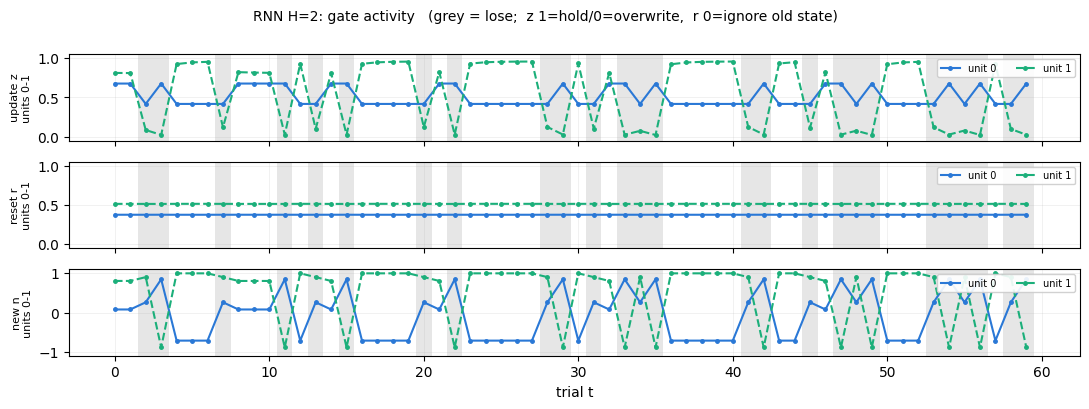

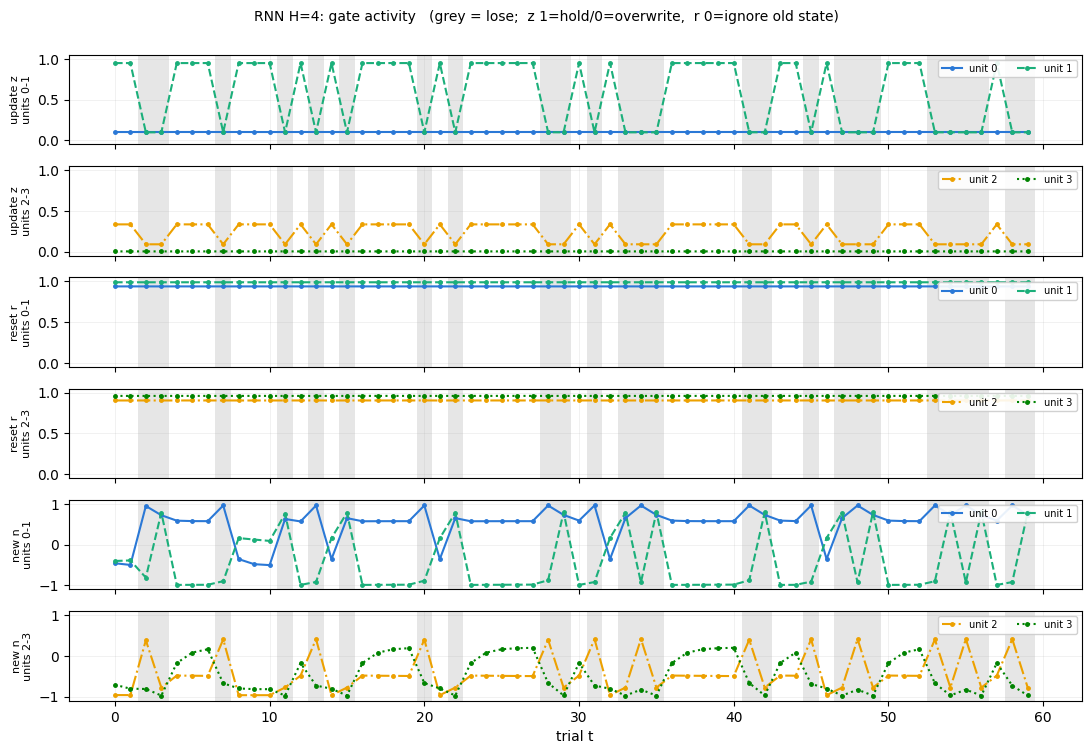

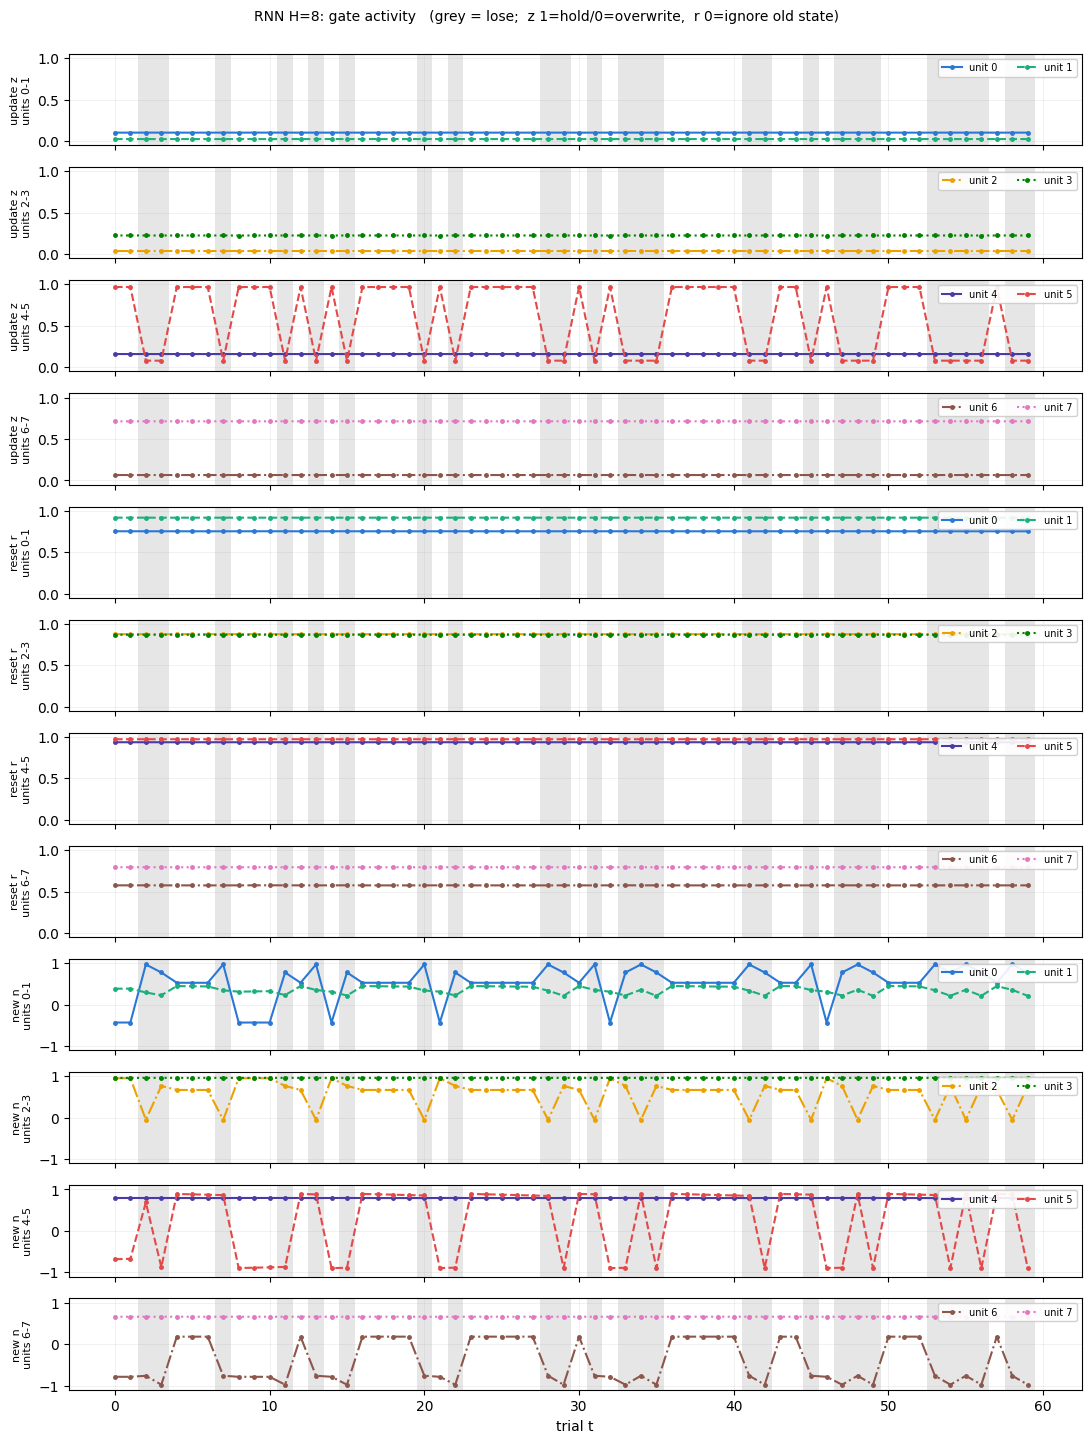

Mean gate value per unit, over the whole example session:

  H=2
     update  [0.501 0.557]
     reset   [0.376 0.515]
     new     [-0.09   0.561]
  H=4
     update  [0.102 0.587 0.23  0.003]
     reset   [0.938 0.989 0.904 0.96 ]
     new     [ 0.579 -0.476 -0.409 -0.429]
  H=8
     update  [0.101 0.024 0.038 0.225 0.16  0.591 0.065 0.713]
     reset   [0.751 0.915 0.875 0.868 0.936 0.972 0.575 0.793]
     new     [ 0.57   0.362  0.569  0.963  0.794  0.312 -0.373  0.66 ]


In [40]:
# --- 9.1 -- What the three gates do, trial by trial ---------------------------------
# Single column, full-width rows so the trial timeline stays readable -- splitting unit-pairs
# across COLUMNS squished the x-axis at H=8. Rows are grouped by gate; <=2 units per panel,
# same convention as §6.3.
GATE_YLABEL = {"update": "update z", "reset": "reset r", "new": "new n"}
for H in H_TO_COMPARE:
    pairs = _unit_pairs(H)                              # defined in §6.3
    rows = [(g, pr) for g in ("update", "reset", "new") for pr in pairs]
    fig, axes = plt.subplots(len(rows), 1, sharex=True, squeeze=False,
                             figsize=(11, 1.15 * len(rows) + 0.6))
    for ax, (g, (u0, u1)) in zip(axes[:, 0], rows):
        shade_losses(ax, example)
        for u in (u0, u1):
            if u >= H:
                continue
            ax.plot(t, gen[H][g][:N_SHOW, u], color=PALETTE[u], ls=LINESTYLES[u],
                    lw=1.5, marker="o", ms=2.5, label=f"unit {u}")
        ax.set_ylim(-1.1, 1.1) if g == "new" else ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.25, lw=0.5); ax.set_axisbelow(True)
        ax.legend(loc="upper right", ncol=2, fontsize=7, framealpha=0.9)
        lbl = f"units {u0}-{u1}" if u1 < H else f"unit {u0}"
        ax.set_ylabel(f"{GATE_YLABEL[g]}\n{lbl}", fontsize=8)
    axes[-1, 0].set_xlabel("trial t")
    fig.suptitle(f"RNN H={H}: gate activity   (grey = lose;  z 1=hold/0=overwrite,  r 0=ignore old state)",
                 y=0.999, fontsize=10)
    plt.tight_layout(); plt.show()

print("Mean gate value per unit, over the whole example session:\n")
for H in H_TO_COMPARE:
    print(f"  H={H}")
    for g in ("update", "reset", "new"):
        print(f"     {g:<7s} {np.round(gen[H][g].mean(axis=0), 3)}")

### 9.2 A caveat: the RNN's rule is only a distribution-bounded approximation

Off-manifold test: feed a constant "won" input for `k` steps. WSLS says stay forever, so `P(stay)`
should be 1 at every `k`. It isn't — past the streak lengths that actually occur (~28), each size
slowly drifts (each on a different arm, so it's a training coin-toss, not a size effect).

So the RNN learned a **distribution-bounded approximation**: right where it saw data, drifting
beyond it — not the exact rule. The FSC's `(action, observation)` lookup has no such crack.
*(det_init still to check.)*

In [41]:
# --- 9.2 -- Off-manifold probe: P(stay) after k consecutive wins ---------------------
streaks = []
for s in encoded_sessions:
    run = 0
    for v in s["observations"]:
        run = run + 1 if v == 1 else 0
        streaks.append(run)
streaks = np.array(streaks)
print(f"Longest win streak anywhere in the data: {streaks.max()} trials.  "
      f"Only {100*np.mean(streaks > 20):.3f}% of trials sit beyond streak 20.\n")

KS = [1, 2, 4, 8, 12, 20, 40, 60]
print("P(stay) after k consecutive wins, driven from h0 with a constant input")
print("(WSLS says every one of these should be 1.000)\n")
print("      k =        " + "".join(f"{k:>7d}" for k in KS))
for H in H_TO_COMPARE:
    for a0 in range(A):
        P = rnn_params[H]; row = []
        for k in KS:
            h = np.zeros(P["H"])
            for _ in range(k):
                h, _ = gru_step(h, rnn_encode_input(a0, 1), P)
            row.append(rnn_action_probs(h, P)[a0])
        print(f"   H={H}, stay on {str(ActSpace[a0]):>2}: " + "".join(f"{v:>7.3f}" for v in row))
print("\nEach size holds one arm rock-steady and lets the other drift -- opposite arms, "
      "\nso this is training symmetry-breaking, not an H=2 deficit.")

Longest win streak anywhere in the data: 28 trials.  Only 0.021% of trials sit beyond streak 20.

P(stay) after k consecutive wins, driven from h0 with a constant input
(WSLS says every one of these should be 1.000)

      k =              1      2      4      8     12     20     40     60
   H=2, stay on -1:   0.883  0.928  0.921  0.818  0.648  0.312  0.058  0.026
   H=2, stay on  1:   0.739  0.897  0.978  0.996  0.998  0.999  0.999  0.999
   H=4, stay on -1:   0.975  0.988  0.984  0.958  0.909  0.755  0.445  0.351
   H=4, stay on  1:   0.930  0.931  0.930  0.948  0.959  0.970  0.976  0.976
   H=8, stay on -1:   0.955  0.964  0.958  0.936  0.910  0.852  0.739  0.690
   H=8, stay on  1:   0.947  0.949  0.931  0.891  0.847  0.755  0.599  0.538

Each size holds one arm rock-steady and lets the other drift -- opposite arms, 
so this is training symmetry-breaking, not an H=2 deficit.


## 10. What we found (random_init)

**1. Both models learn WSLS; only the FSC learns it exactly.** Every RNN size reproduces
win-stay/lose-shift and matches the data's action matrix to ~0.002 (§6.1–6.4). The FSC matches it
exactly (0.00000, hard 0/1 policy) — because its transition *is* a lookup on `(action, observation)`,
the very thing the matrix conditions on. The RNN has to approximate the same rule in continuous state.

**2. H=2 and H=4 are behaviorally identical** (§6.1–6.4): same stay/shift rates, same action matrix
to three decimals. Any difference is in *how* they compute, not *what* they do.

**3. The one robust difference is the first action** (§6.5): H=2 is consistently skewed, H=4 is not.
`h0` is fixed at zero, so `P(A_0) = softmax(readout bias)` — but that bias also shifts every other
trial, so with few units the network can't both place its two states symmetrically and keep the bias
neutral; the prior and the policy fight over one parameter. This is the clearest case of *why* the
FSC is more interpretable: it keeps the prior (`rho`), policy, and transition as separate named
parts, where the RNN shares them in one weight matrix — so trial 0 comes out wrong at H=2.

**4. Extra capacity buys redundancy, not new content** (§5.3, §7): both hidden states are effectively
~1–2 dimensional whatever H is; larger H just spreads the same one bit across more units.

**5. No RNN holds the rule off-manifold** (§9.2): each drifts on long streaks, on a *different* arm —
a training symmetry-breaking artifact, not a size effect. These RNNs implement WSLS as a slow
transient tuned to the streak lengths that occur, not a stable fixed point.

**Caveats.** Runs at each size are outer folds of one cross-validation — read spreads as consistency,
not error bars. And this is one deterministic one-bit task: the right setting to *validate* these
probes, the wrong one to generalize about when RNN capacity pays off. That needs a noisier or
longer-memory dataset — what the pipeline is built to be re-pointed at.

## 11. det_init: what we found, and what's still open

**Scope note.** Section 10 above is the original `random_init` analysis and its conclusions
are specific to that dataset (in particular, its claim that "H=2 is skewed where H=4 is not"
does *not* hold for `det_init` -- see below). This section covers `det_init` only, run through
the same pipeline, unchanged, with `H_TO_COMPARE = [2, 4, 8]`.

**1. The FSC's story is identical to `random_init`'s.** `M* = 2`, same parsimony argument, same
clean 50/50 state occupancy, same perfect split of the 4 `(prev action, prev outcome)` contexts
across the two states (§5.1).

**2. The RNN picked a much larger size: `H* = 8`**, versus `random_init`'s actual `H* = 5`
(a number we had to re-derive live in this notebook -- an earlier "H=4" we'd been citing turned
out to be stale prose from before this run, not a recomputation, and is corrected here).

**3. The H=8 pick is real but statistically fragile, and it is *not* overfitting.** Tracing the
exact paired t-test behind model selection (§3.3's own statistic): H=8 beats H=4 on all 5 outer
cross-validation folds (not one lucky fold), but only at p=0.029 -- the single comparison, out of
seven run for H=8, that would *not* survive even a mild multiple-comparisons correction. And
train/val/trainval/test loss are all ~0.0003 for both H=4 and H=8 with no gap between them, which
rules out classic overfitting (train much better than test) as the explanation.

**4. H=8 uses more real capacity than H=4, but only modestly, and it buys nothing behaviorally**
(§5.3). Participation ratio (effective dimensions actually used): H=2 -> 1.82, H=4 -> 1.77,
H=8 -> 2.83. So H=8 is genuinely less compressed than H=4 -- a real, measurable difference --
but still far from using all 8 units, and on ordinary trials its behavior is indistinguishable
from (and on the action-transition matrix, very slightly worse than) H=4's (§6.4).

**5. The headline finding (§6.6): the FSC and RNN diverge specifically on how well they can
represent* certainty*, and the gap scales with how deterministic the true answer is.**

| dataset | real P(first action) | FSC | RNN (H*) |
|---|---|---|---|
| `random_init` | 0.4880 | 0.4881 | 0.4813 (H=5) |
| `det_init` | 1.0000 | 1.0000 | 0.9739 (H=8) |

The FSC matches the true first-action distribution almost exactly in *both* cases -- it has a
dedicated parameter (`rho`) for this, free of any other job. The RNN's first-action probability
comes from `softmax(one shared readout bias)`, which *also* shapes every other trial's
prediction, so it can't be pushed to an extreme without a cost elsewhere. That cost is small when
the true answer is near 50/50 and large when it's a hard deterministic spike -- and more hidden
units don't fix it (§6.5: H=8 doesn't outperform H=2 here). This is a structural difference
between the two paradigms, not a capacity shortfall, and it is the clearest evidence in this
notebook that the FSC and RNN are not simply interchangeable at representing certainty, even
though they agree almost everywhere else.

**Open questions -- deliberately not chased further in this pass:**

- **Why does `det_init` need roughly one more effective dimension than `random_init`'s
  RNN does?** The live hypothesis is that a *fixed* first action forces the network to spend
  extra capacity isolating "trial-0-only" behavior from the general WSLS policy in a way a
  *random* first action doesn't. Untested -- would need a with/without-trial-0 comparison of the
  kind scoped out earlier in this project's discussion but not yet run.
- **Is `H*=8` stable?** Given how fragile the underlying statistic is (point 3 above), it's
  worth checking whether a different random seed or more outer folds changes the pick.
- **Is WSLS simply too easy to ever make the RNN's extra capacity pay off?** Both datasets are
  near-deterministic one-bit rules -- the right setting to *validate* these diagnostics (we know
  the answer, and they recover it), the wrong one to conclude anything general about when extra
  RNN capacity is worth it. That needs a noisier or longer-memory dataset -- the natural next
  experiment, on either initialization.
